In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# DATA CLEANING

In [2]:
N = 100

folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"

joint_files = {
    1: "J_1_12.06.2026_13_05_36.csv",
    2: "J_2_12.06.2026_13_22_35.csv",
    3: "J_3_12.06.2026_13_13_15.csv",
    5: "J_5_12.06.2026_13_14_50.csv"
}

# CSV CONTAINS ONLY RESPECTIVE PARAMETERS

In [3]:
for joint_no, filename in joint_files.items():
    # Read original file
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    # Keep only the corresponding joint columns
    clean_df = df[
        [
            'timestamp',
            f'm_t_{joint_no}',
            f'jts{joint_no}',
            f'v{joint_no}',
            f'q{joint_no}'
        ]
    ].copy()
    # Save with original column names
    output_file = os.path.join(folder_path, f'Joint_{joint_no}_Clean.csv')
    clean_df.to_csv(output_file, index=False)
    print(f"Saved: {output_file}")

Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\Joint_1_Clean.csv
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\Joint_2_Clean.csv
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\Joint_3_Clean.csv
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\Joint_5_Clean.csv


# WORKING ON RAW DATA

In [4]:
all_files = {
    1: "Joint_1_Clean.csv",
    2: "Joint_2_Clean.csv",
    3: "Joint_3_Clean.csv",
    5: "Joint_5_Clean.csv"
}

In [5]:
def friction(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v / Vs) + Bv * v)


JOINT 1


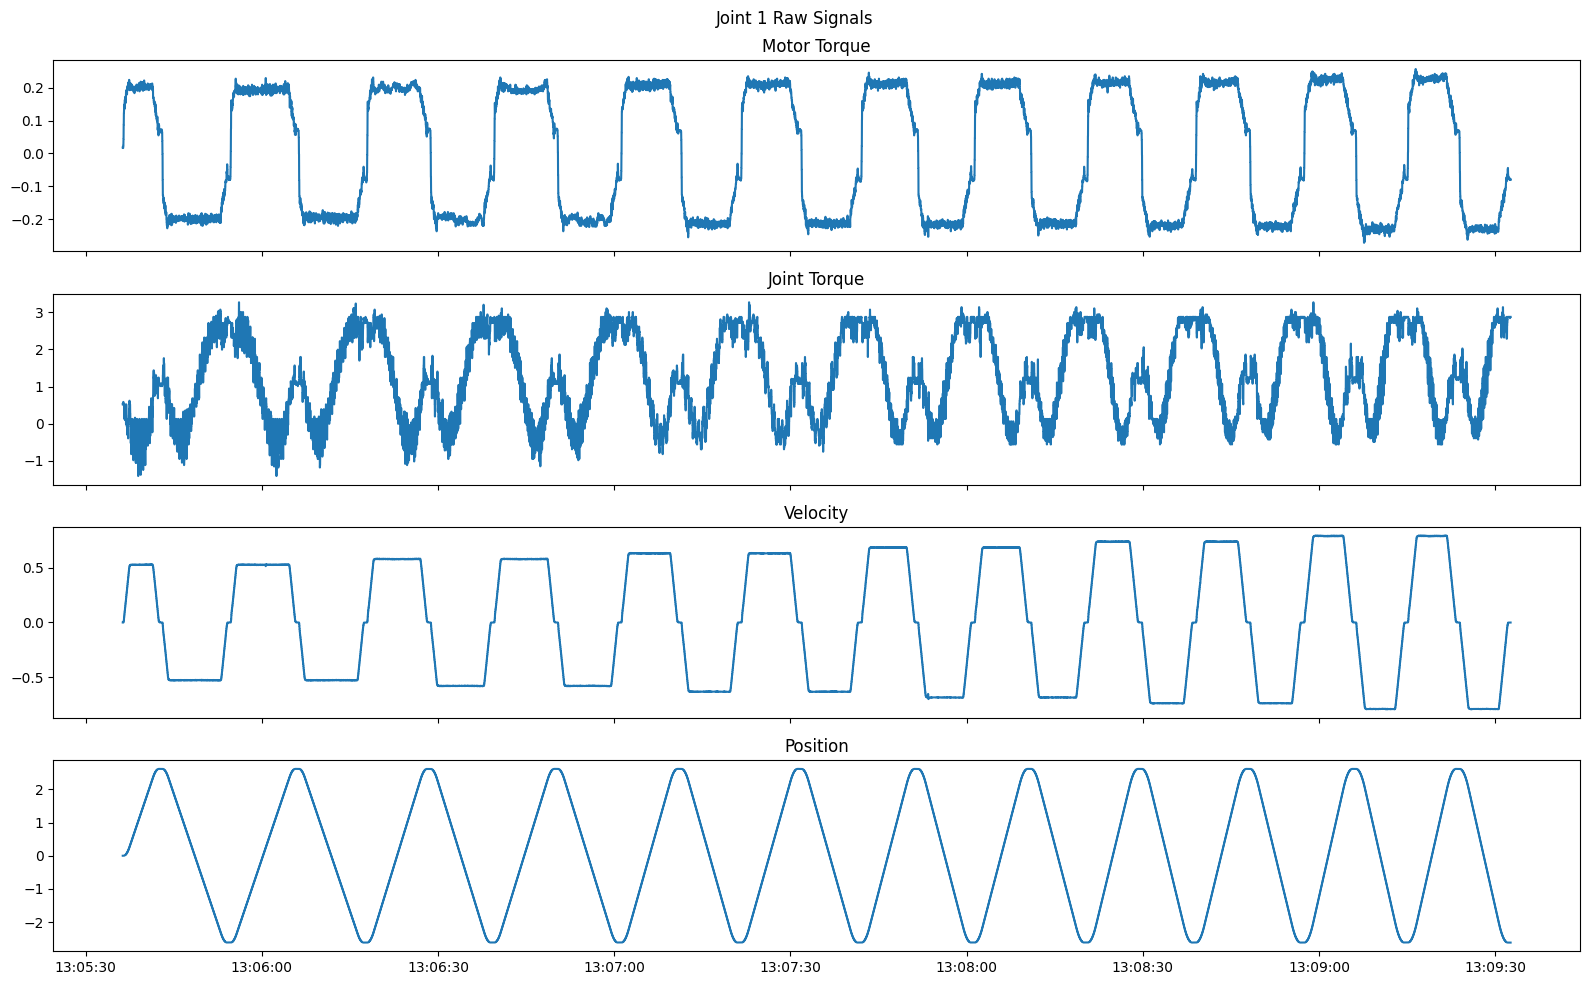

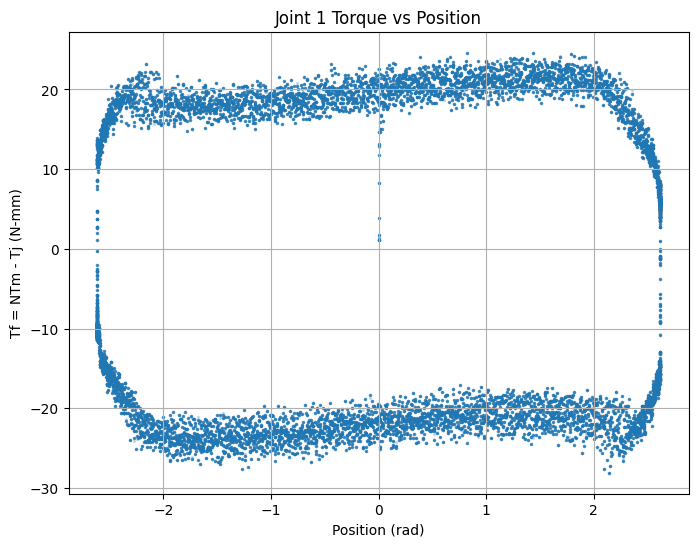


Tc = 9.289417
Bv = 18.728337
Vs = 0.000226

RMSE = 2.8043
MAE = 2.1405
R² = 0.9799


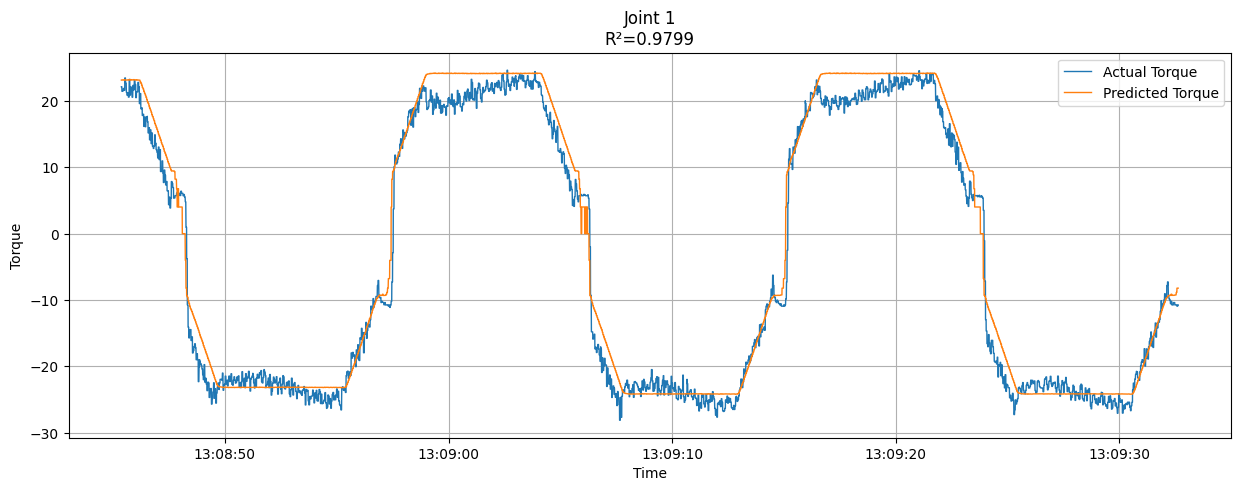

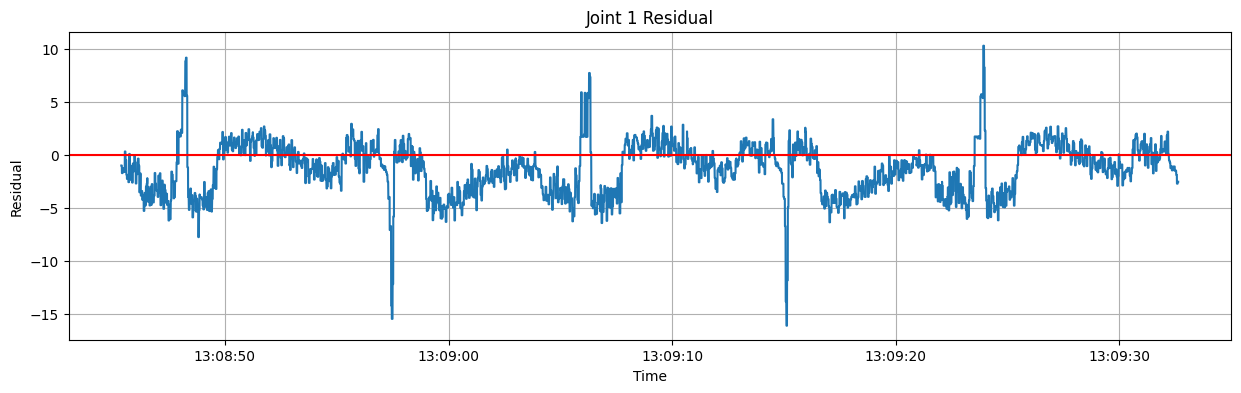

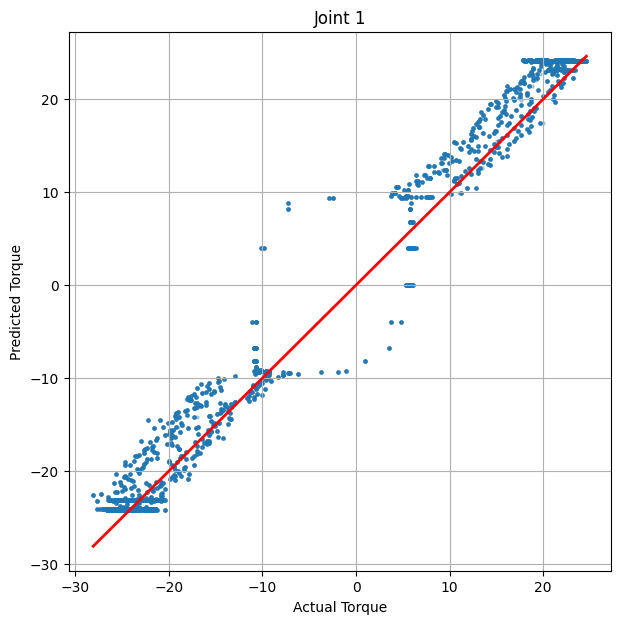

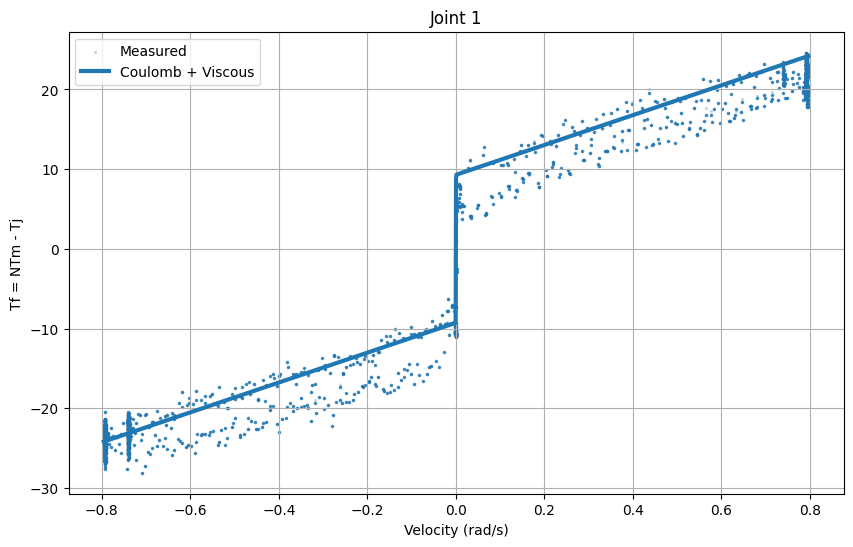


JOINT 2


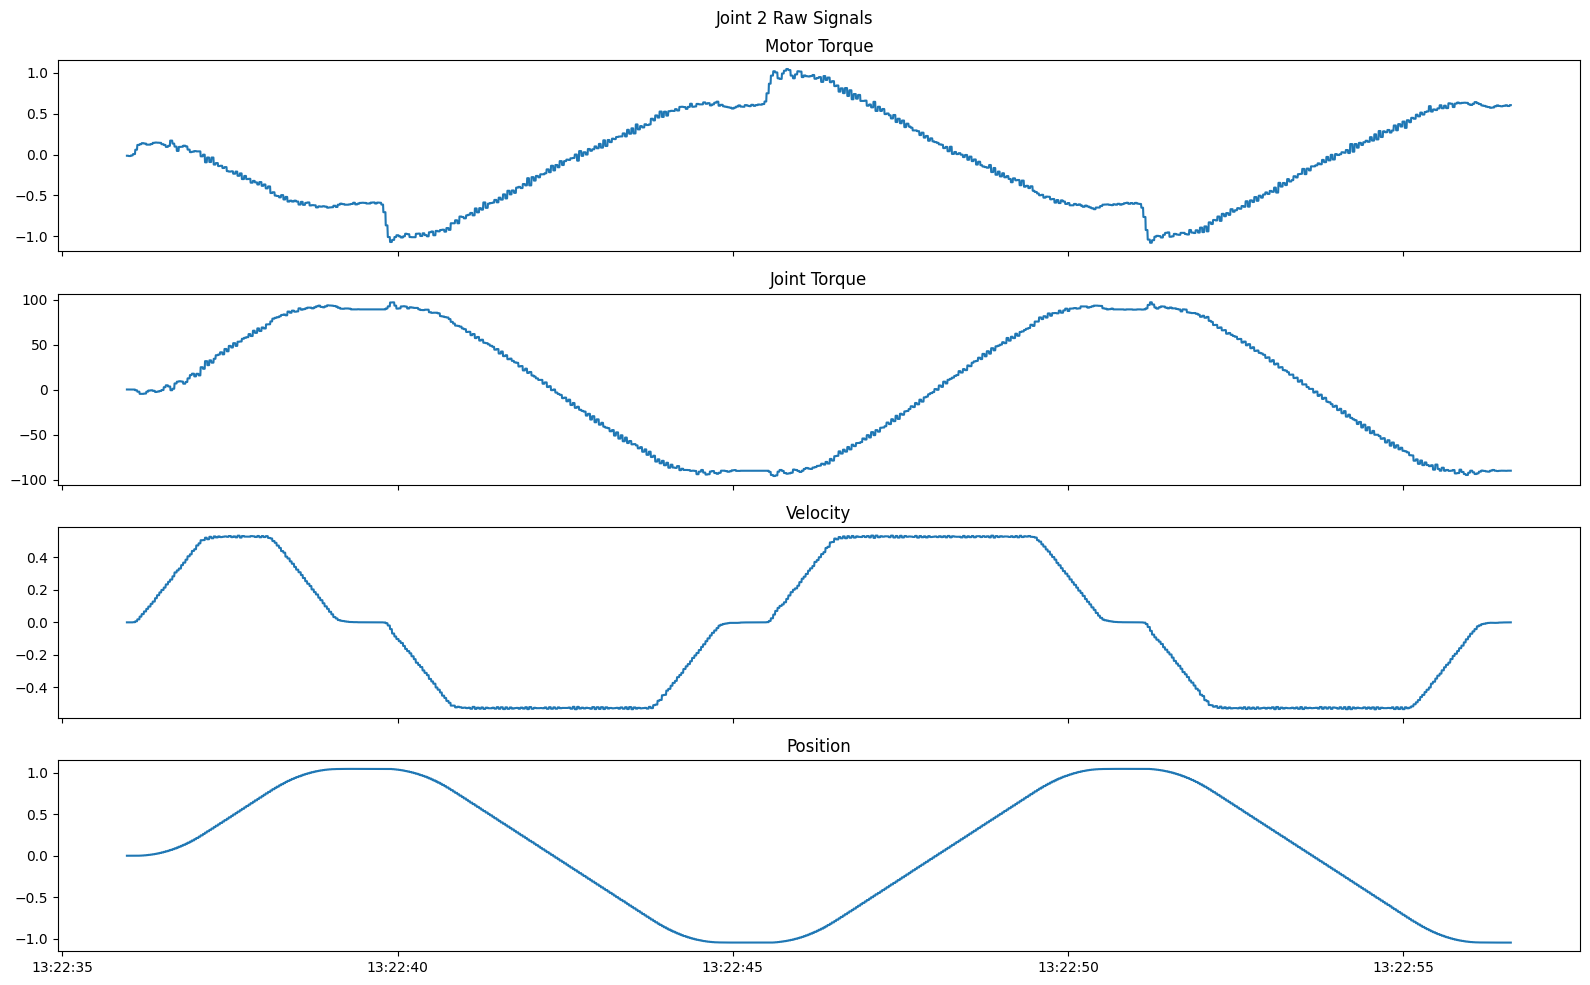

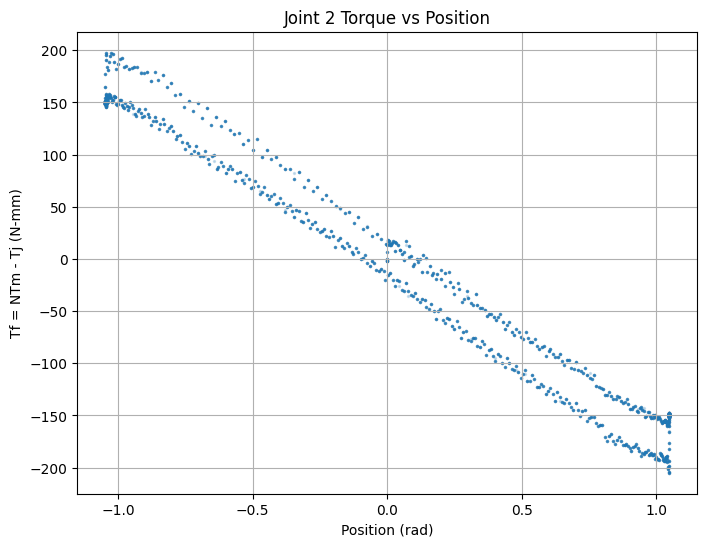


Tc = 20.430476
Bv = -4.231243
Vs = 0.141178

RMSE = 110.9008
MAE = 97.0023
R² = -0.4533


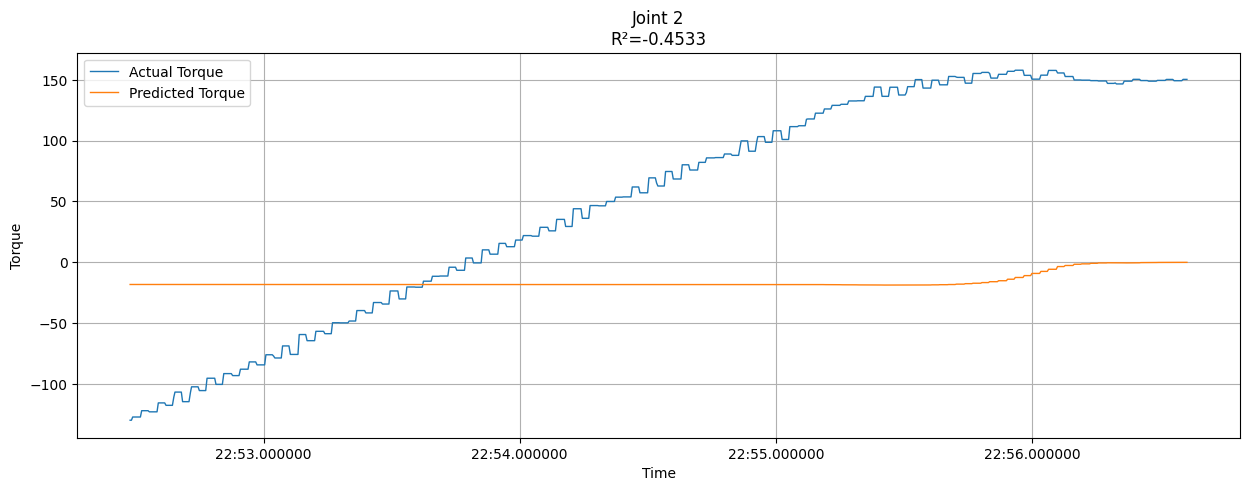

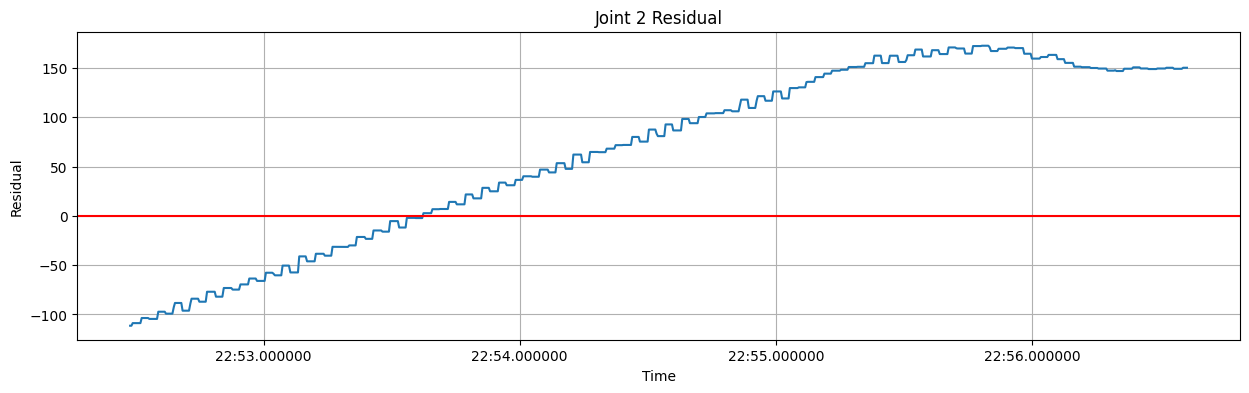

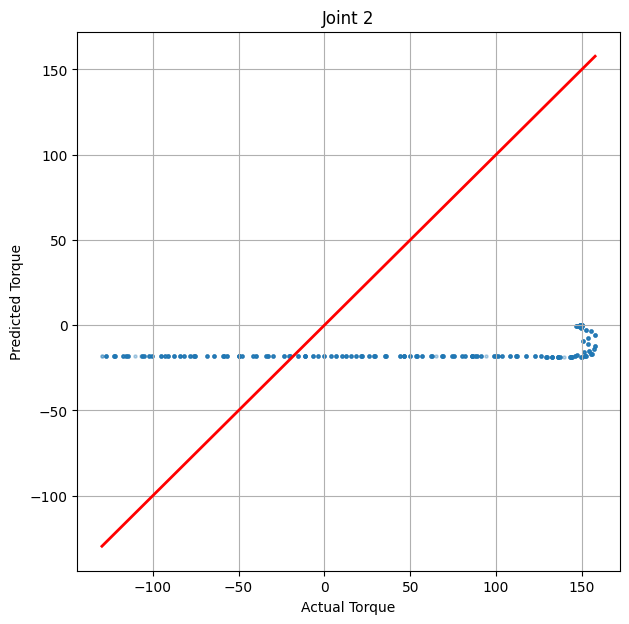

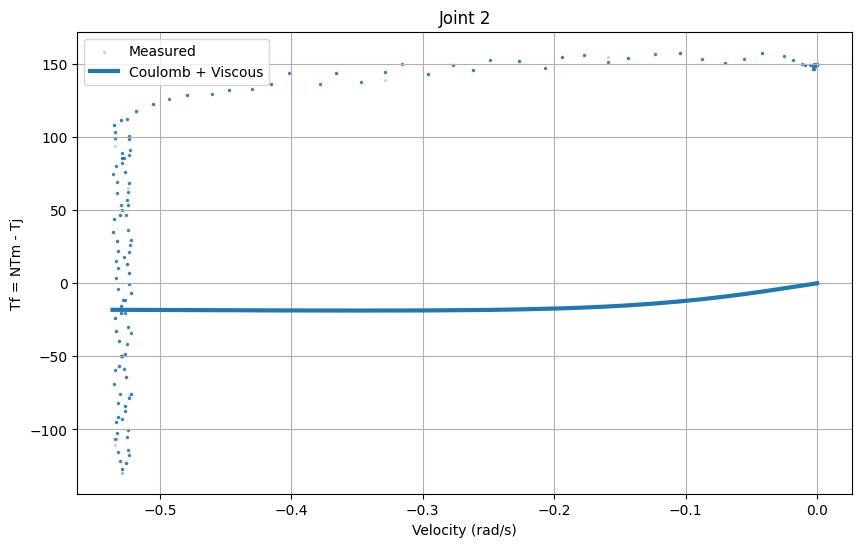


JOINT 3


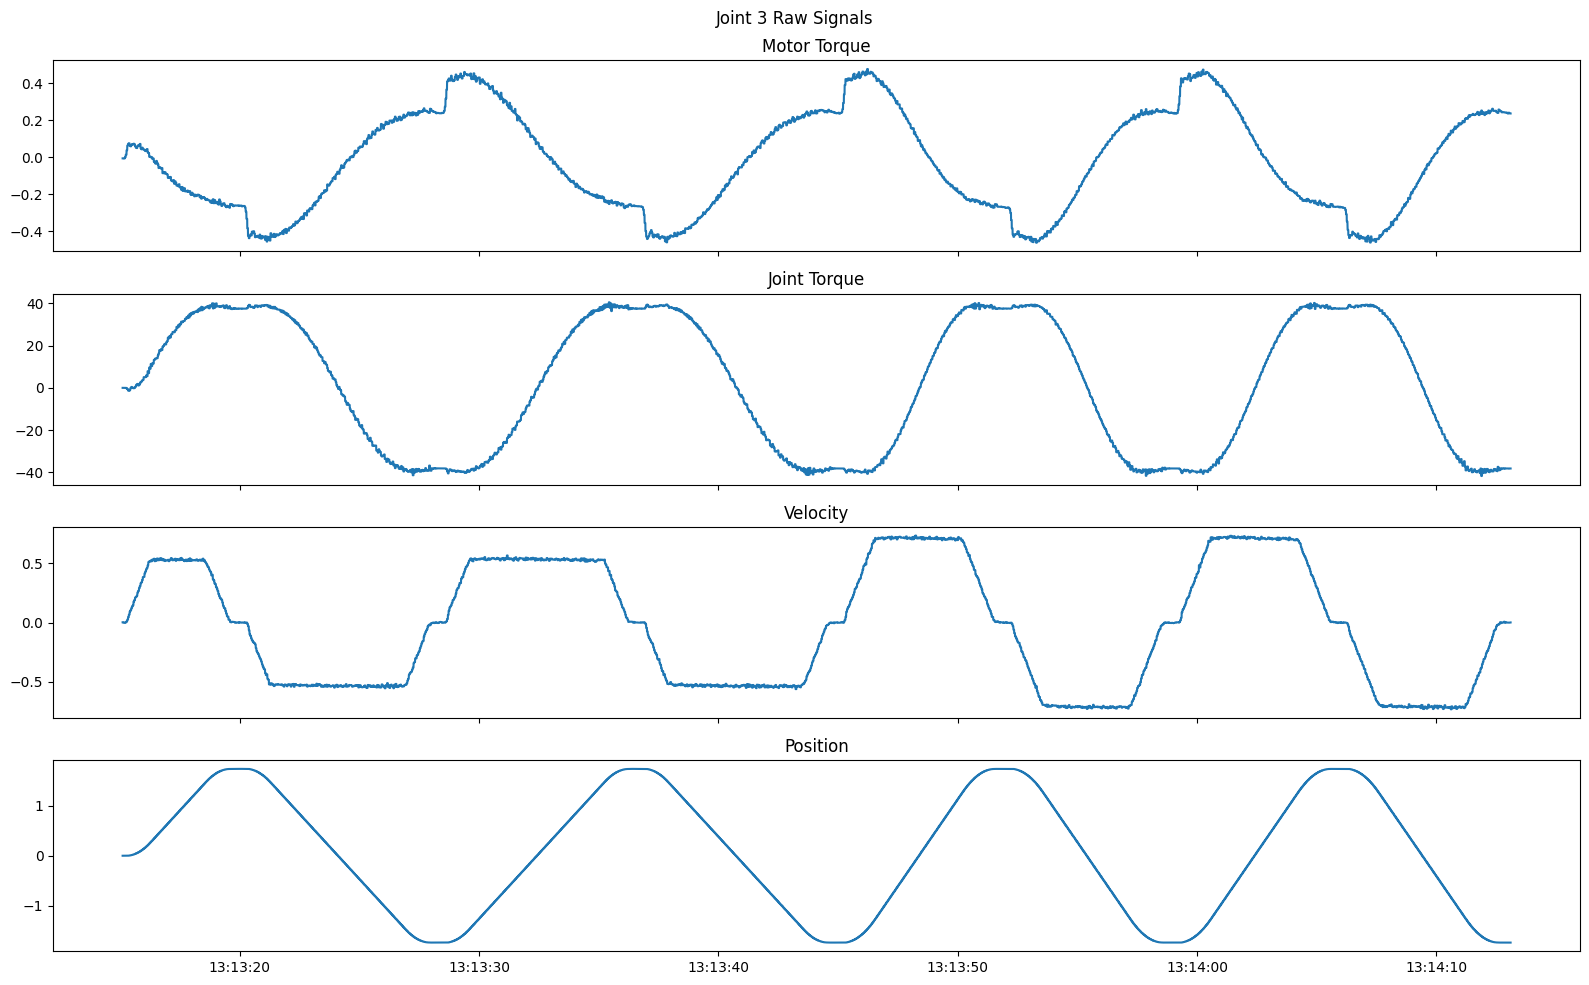

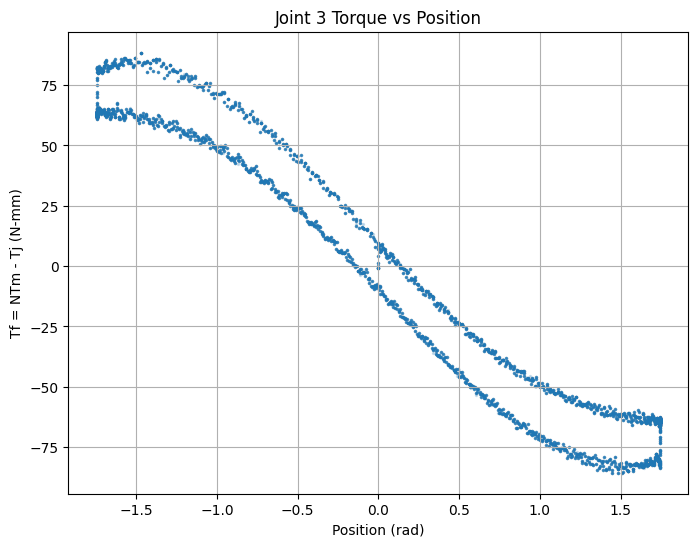


Tc = -22882.636511
Bv = 4004.495612
Vs = 5.716781

RMSE = 56.6801
MAE = 52.0322
R² = -0.1427


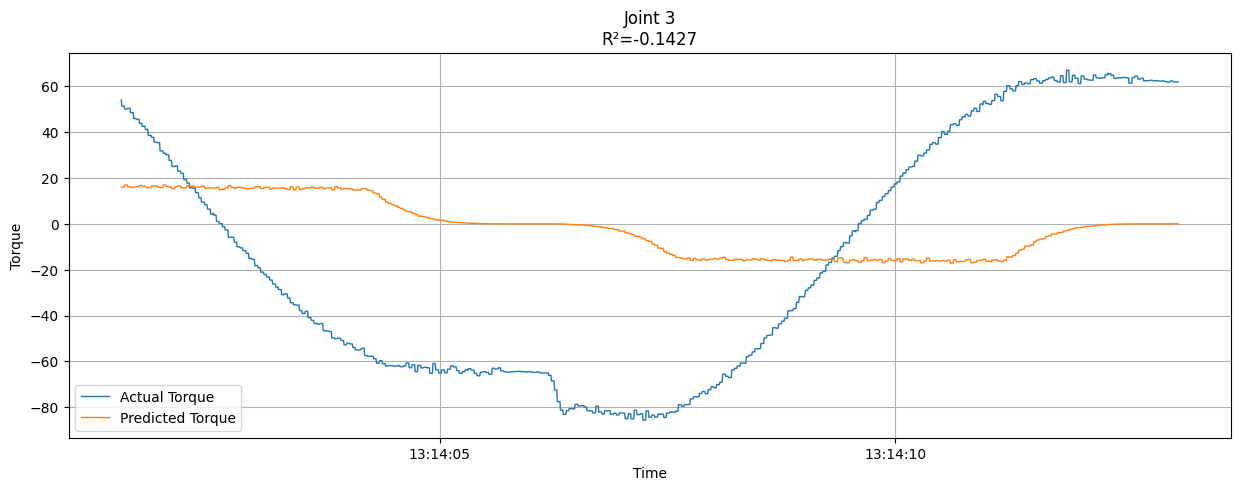

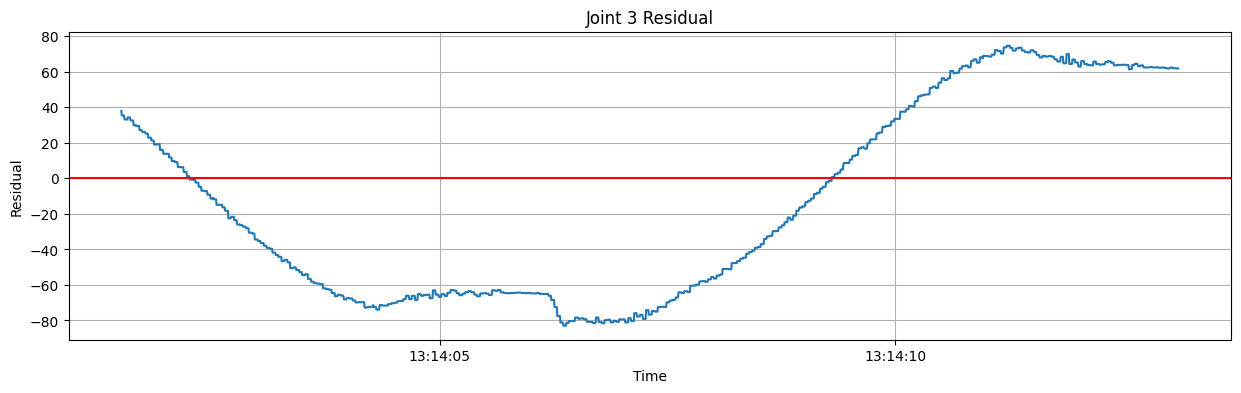

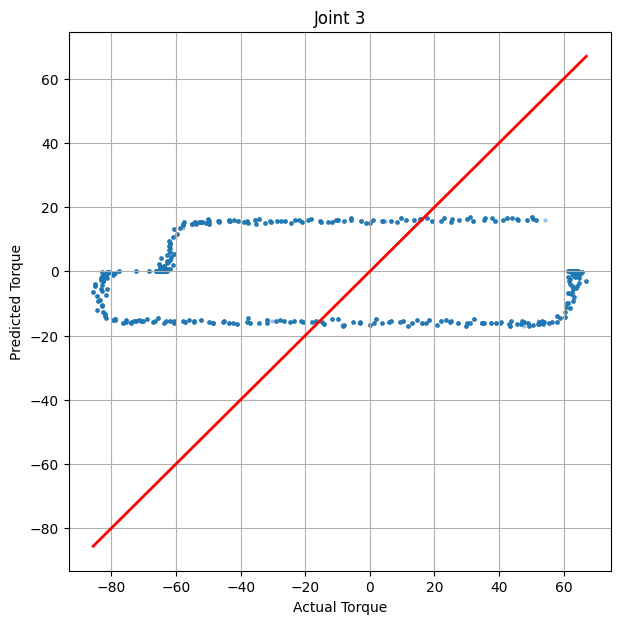

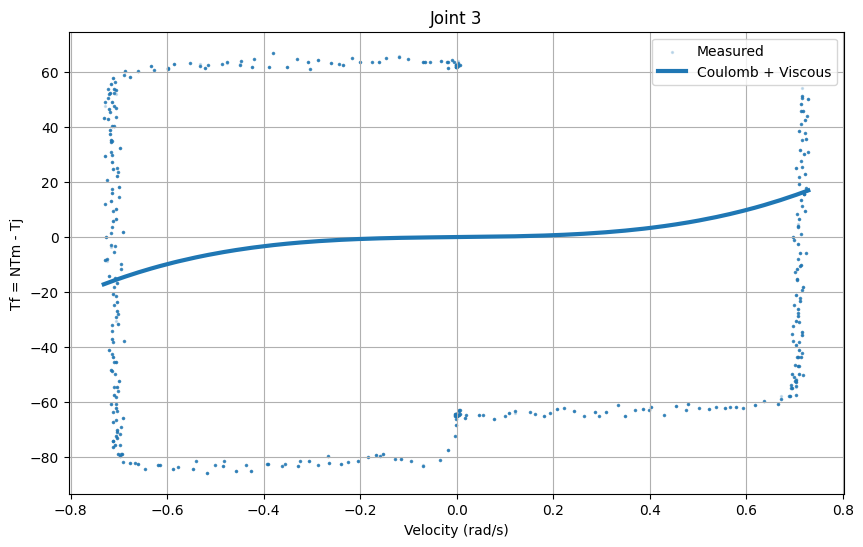


JOINT 5


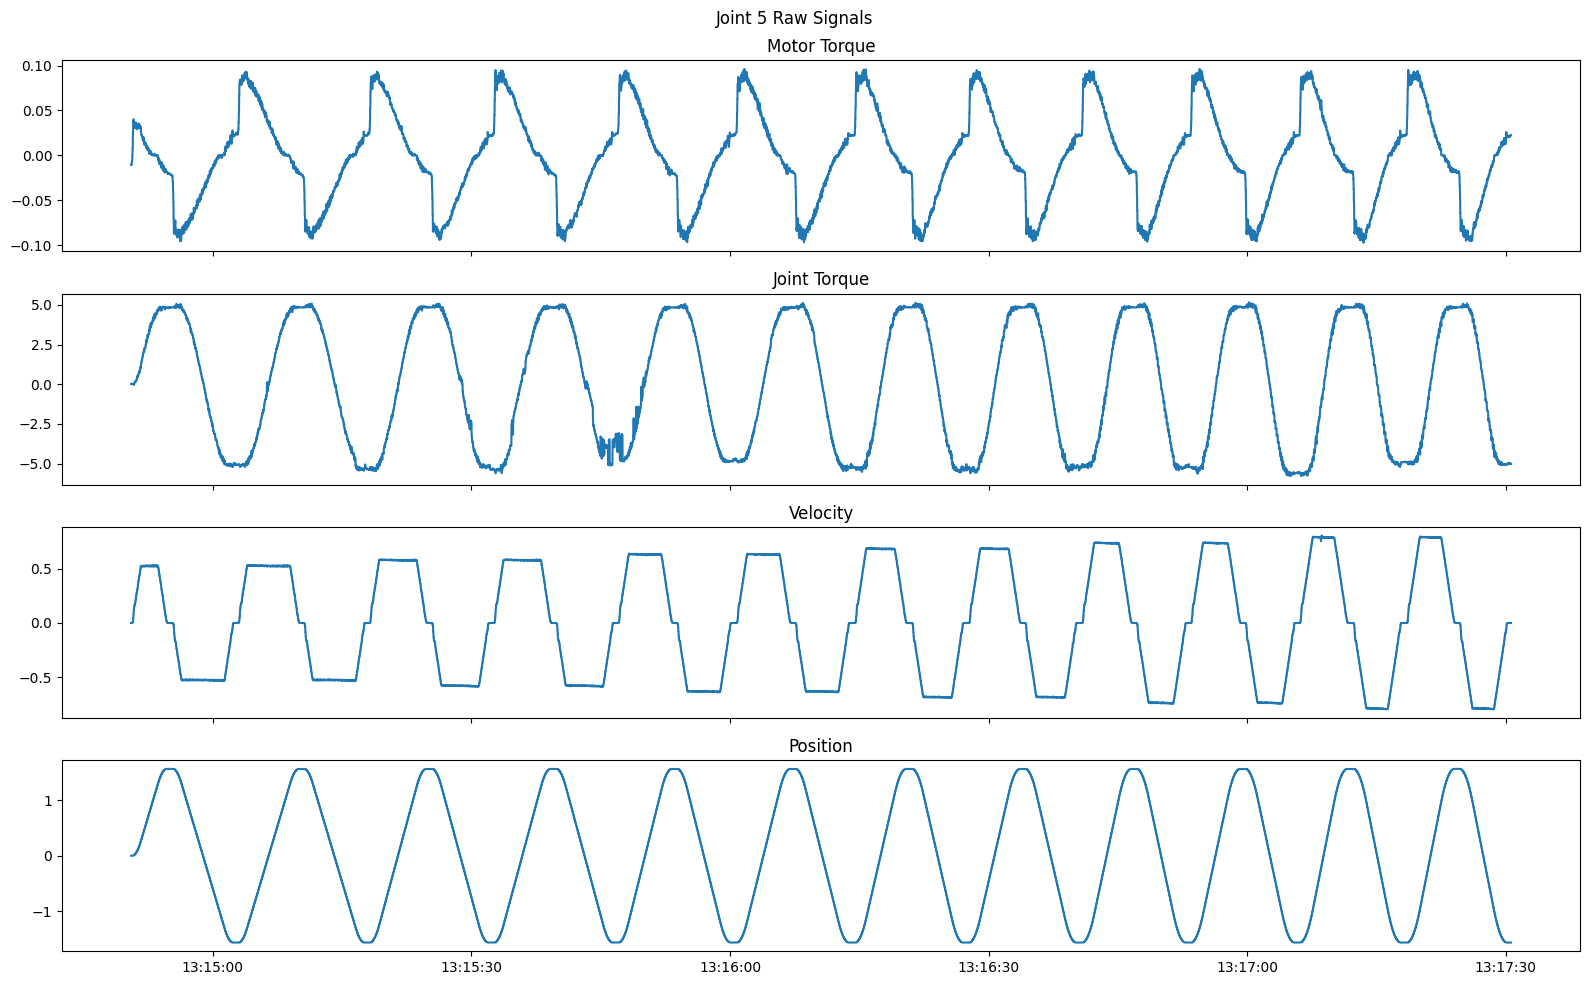

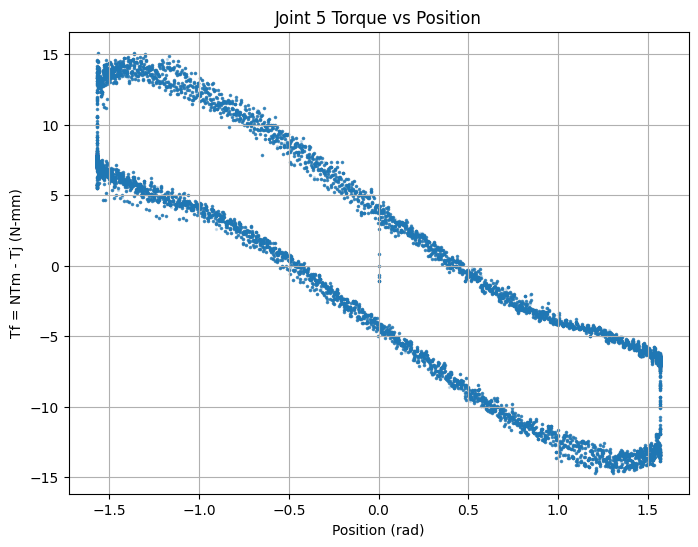


Tc = 3.291972
Bv = 1.033772
Vs = 0.160190

RMSE = 7.7905
MAE = 7.2178
R² = 0.1798


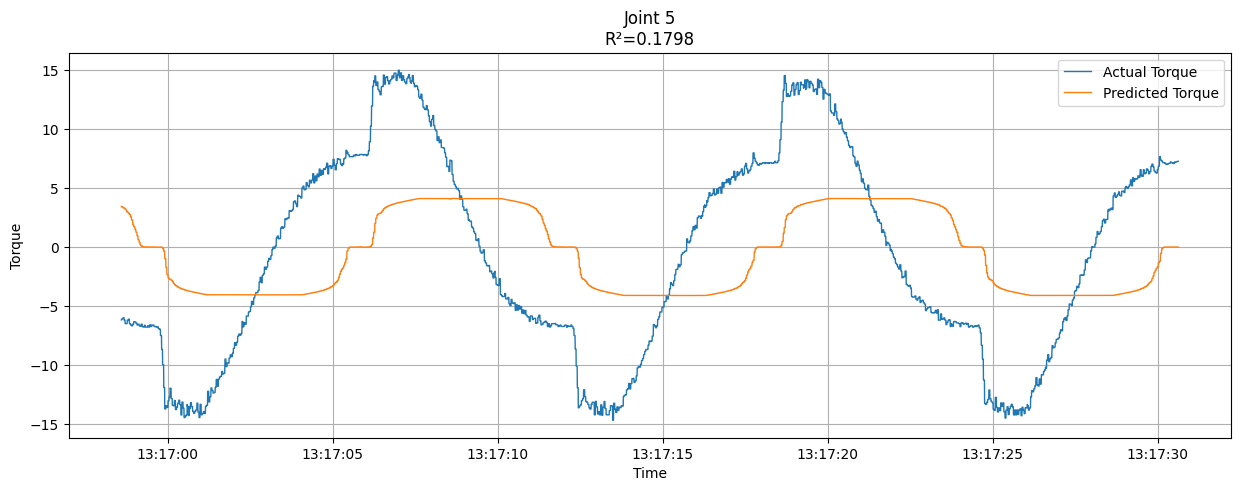

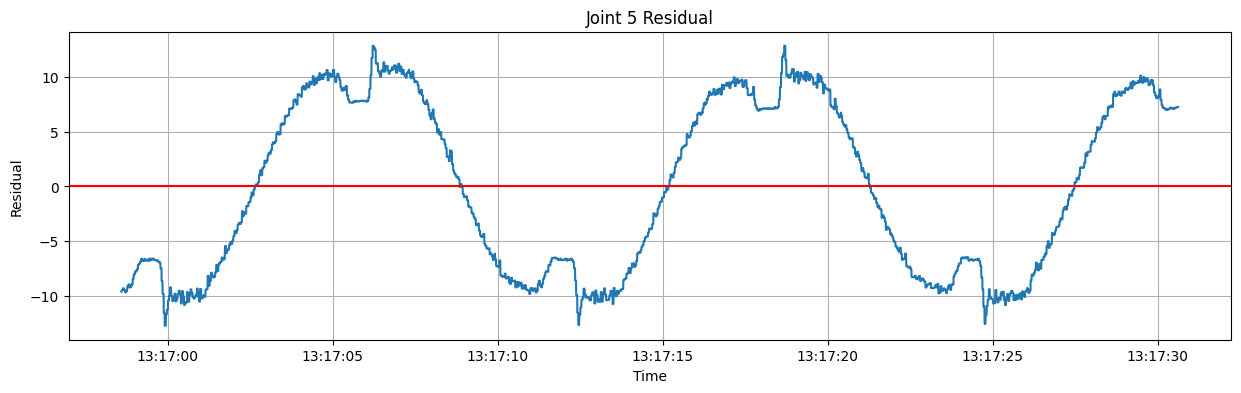

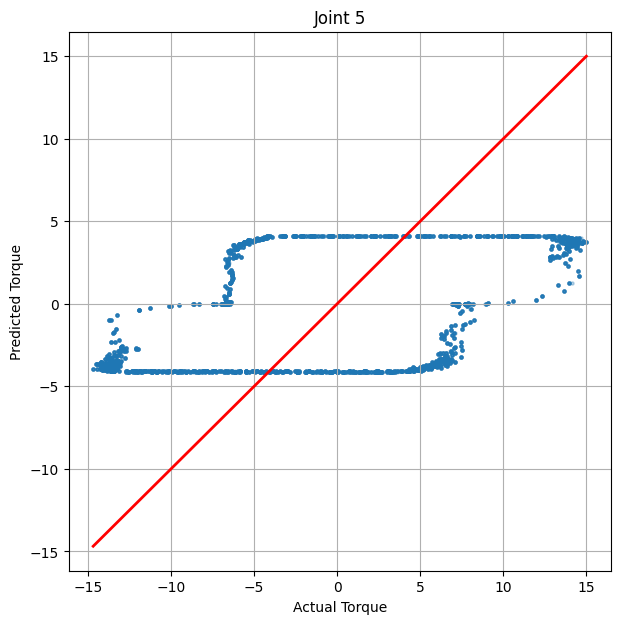

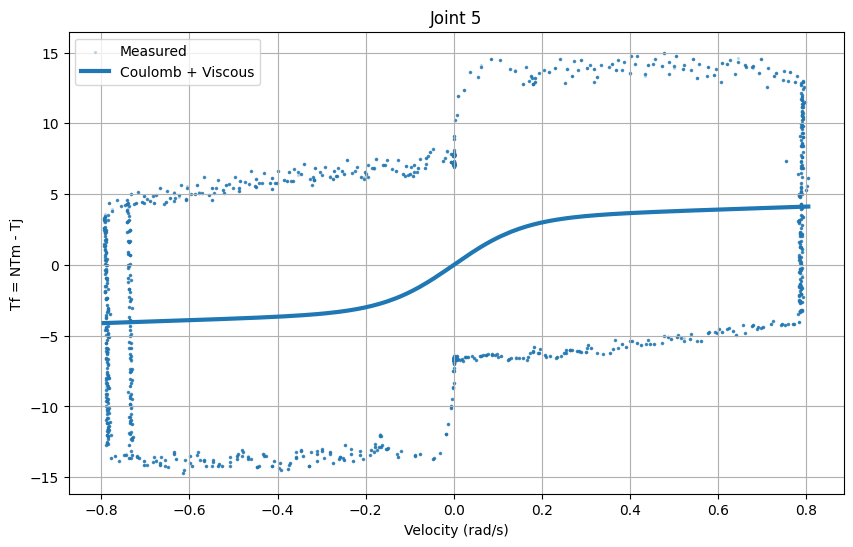

In [6]:
for joint, filename in all_files.items():
    print("\n" + "=" * 70)
    print(f"JOINT {joint}")
    print("=" * 70)
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    # ==========================================
    # TIMESTAMP
    # ==========================================
    df["timestamp"] = pd.to_datetime("2026-06-12 " + df["timestamp"].astype(str))

    # ==========================================
    # COMMON COLUMNS
    # ==========================================
    df["q"] = np.deg2rad(df[f"q{joint}"])
    df["v"] = np.deg2rad(df[f"v{joint}"])
    df["tm"] = df[f"m_t_{joint}"]
    df["tj"] = df[f"jts{joint}"]
    df["tf"] = (N * df["tm"] - df["tj"])

    # ==========================================
    # RAW SIGNALS VS TIME
    # ==========================================
    fig, ax = plt.subplots(
        4,
        1,
        figsize=(16,10),
        sharex=True
    )
    ax[0].plot(df["timestamp"], df["tm"])
    ax[0].set_title("Motor Torque")
    ax[1].plot(df["timestamp"], df["tj"])
    ax[1].set_title("Joint Torque")
    ax[2].plot(df["timestamp"], df["v"])
    ax[2].set_title("Velocity")
    ax[3].plot(df["timestamp"], df["q"])
    ax[3].set_title("Position")
    plt.suptitle(f"Joint {joint} Raw Signals")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # TORQUE VS POSITION
    # ==========================================
    plt.figure(figsize=(8,6))
    plt.scatter(df["q"], df["tf"], s=2, alpha=0.2)
    plt.xlabel("Position (rad)")
    plt.ylabel("Tf = NTm - Tj (N-mm)")
    plt.title(f"Joint {joint} Torque vs Position")
    plt.grid(True)
    plt.show()

    # ==========================================
    # TRAIN / VAL / TEST
    # ==========================================
    size = len(df)
    train_end = int(0.60 * size)
    val_end = int(0.80 * size)
    train_df = df.iloc[ : train_end]
    val_df = df.iloc[train_end : val_end]
    test_df = df.iloc[val_end : ]

    # ==========================================
    # TRAIN
    # ==========================================
    v_train = train_df["v"].values
    tf_train = train_df["tf"].values
    p0 = [5, 0.1, 0.01]
    params, _ = curve_fit(
        friction,
        v_train,
        tf_train,
        p0=p0,
        maxfev=50000
    )
    Tc, Bv, Vs = params
    print()
    print(f"Tc = {Tc:.6f}")
    print(f"Bv = {Bv:.6f}")
    print(f"Vs = {Vs:.6f}")

    # ==========================================
    # TEST
    # ==========================================
    v_test = test_df["v"].values
    tf_test = test_df["tf"].values
    pred = friction(v_test, *params)
    test_time = test_df["timestamp"]
    rmse = np.sqrt(mean_squared_error(tf_test, pred))
    mae = mean_absolute_error(tf_test, pred)
    r2 = r2_score(tf_test, pred)
    print()
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"R² = {r2:.4f}")

    # ==========================================
    # ACTUAL VS PREDICTED
    # ==========================================
    plt.figure(figsize=(15,5))
    plt.plot(test_time, tf_test, label="Actual Torque", linewidth=1)
    plt.plot(test_time, pred, label="Predicted Torque", linewidth=1)
    plt.title(f"Joint {joint}\nR²={r2:.4f}")
    plt.xlabel("Time")
    plt.ylabel("Torque")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ==========================================
    # RESIDUAL VS TIME
    # ==========================================
    residual = (tf_test - pred)
    plt.figure(figsize=(15,4))
    plt.plot(test_time, residual)
    plt.axhline(0, color="red")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.title(f"Joint {joint} Residual")
    plt.grid(True)
    plt.show()

    # ==========================================
    # ACTUAL VS PREDICTED SCATTER
    # ==========================================
    plt.figure(figsize=(7,7))
    plt.scatter(tf_test, pred, s=5, alpha=0.3)
    mn = min(tf_test.min(), pred.min())
    mx = max(tf_test.max(), pred.max())
    plt.plot([mn,mx], [mn,mx], 'r', linewidth=2)
    plt.xlabel("Actual Torque")
    plt.ylabel("Predicted Torque")
    plt.title(f"Joint {joint}")
    plt.grid(True)
    plt.show()

    # ==========================================
    # FRICTION CURVE
    # ==========================================
    idx = np.argsort(v_test)
    plt.figure(figsize=(10,6))
    plt.scatter(v_test, tf_test, s=2, alpha=0.2, label="Measured")
    plt.plot(v_test[idx], pred[idx], linewidth=3, label="Coulomb + Viscous")
    plt.xlabel("Velocity (rad/s)")
    plt.ylabel("Tf = NTm - Tj")
    plt.title(f"Joint {joint}")
    plt.legend()
    plt.grid(True)
    plt.show()

# REMOVING TIME-SERIES COLOUMN AND DELETING DUPLICATE ROWS

In [7]:
files = {
    1: "Joint_1_Clean.csv",
    2: "Joint_2_Clean.csv",
    3: "Joint_3_Clean.csv",
    5: "Joint_5_Clean.csv"
}

for joint, file in files.items():
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    # Remove timestamp
    if 'timestamp' in df.columns:
        df.drop(columns=['timestamp'], inplace=True)
    mt_col  = f"m_t_{joint}"
    jts_col = f"jts{joint}"
    v_col   = f"v{joint}"
    q_col   = f"q{joint}"
    # Keep only first row when state changes
    df_unique = df.loc[
        df[[mt_col, jts_col, v_col, q_col]]
        .ne(df[[mt_col, jts_col, v_col, q_col]].shift())
        .any(axis=1)
    ].reset_index(drop=True)
    print("\n" + "=" * 50)
    print(f"Joint {joint}")
    print(f"Original rows : {len(df)}")
    print(f"Unique rows : {len(df_unique)}")
    print(f"Removed rows : {len(df)-len(df_unique)}")
    output_file = os.path.join(folder_path, f"{joint}_Unique.csv")
    df_unique.to_csv(output_file, index=False)
    print(f"Saved: {output_file}")
print("\nAll files processed successfully.")


Joint 1
Original rows : 47265
Unique rows : 7709
Removed rows : 39556
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\1_Unique.csv

Joint 2
Original rows : 4129
Unique rows : 672
Removed rows : 3457
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\2_Unique.csv

Joint 3
Original rows : 11602
Unique rows : 1911
Removed rows : 9691
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\3_Unique.csv

Joint 5
Original rows : 32023
Unique rows : 5233
Removed rows : 26790
Saved: S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026\5_Unique.csv

All files processed successfully.


# WORK STARTED

In [8]:
work_files = {
    1: "1_Unique.csv",
    2: "2_Unique.csv",
    3: "3_Unique.csv",
    5: "5_Unique.csv"
}

In [9]:
def friction_model_unique(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v / Vs) + Bv * v)

In [10]:
results = []


JOINT 1
Columns:
['m_t_1', 'jts1', 'v1', 'q1']

Train : (5396, 1)
Val : (771, 1)
Test : (1542, 1)

Estimated Parameters
Tc = 9.614033740687162
Bv = 17.528044285313488
Vs = 0.00023591424524409342

Validation R² = 0.9812

Performance
RMSE = 2.6019
MAE = 1.9599
R² = 0.9818


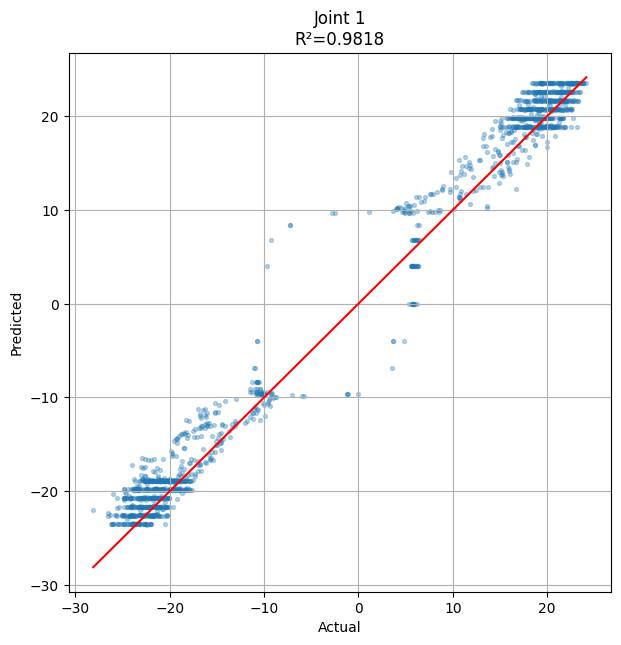

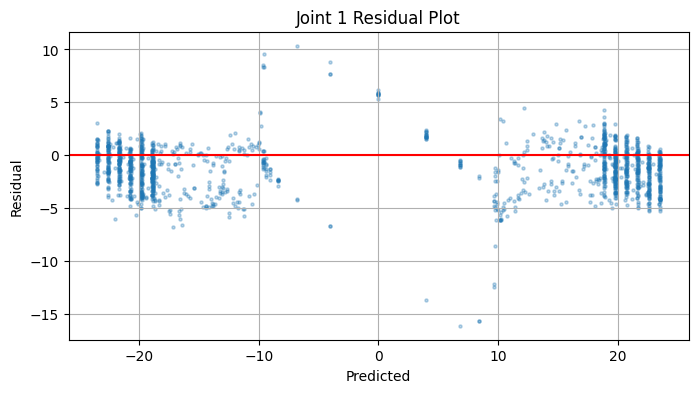

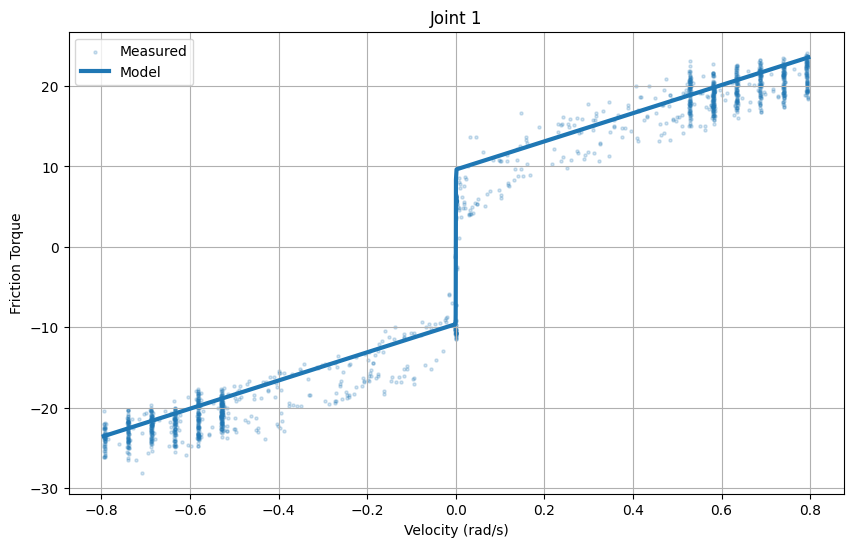


JOINT 2
Columns:
['m_t_2', 'jts2', 'v2', 'q2']

Train : (470, 1)
Val : (67, 1)
Test : (135, 1)

Estimated Parameters
Tc = -52.69936745592357
Bv = 128.59395559229884
Vs = 7.004680556883579e-05

Validation R² = 0.0615

Performance
RMSE = 124.1771
MAE = 111.3301
R² = 0.0574


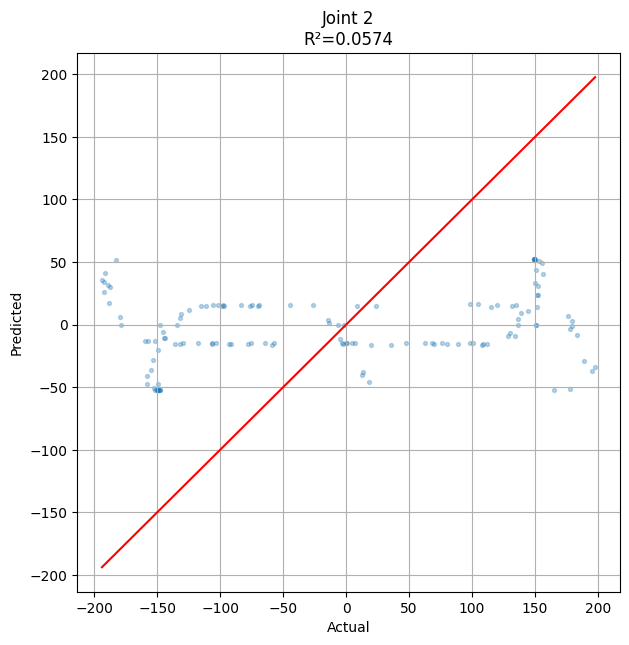

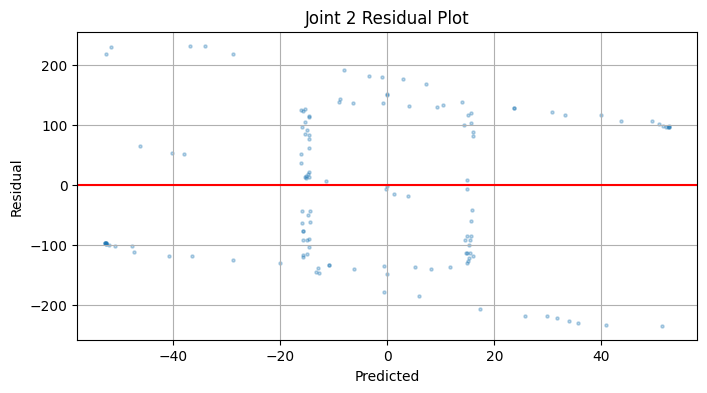

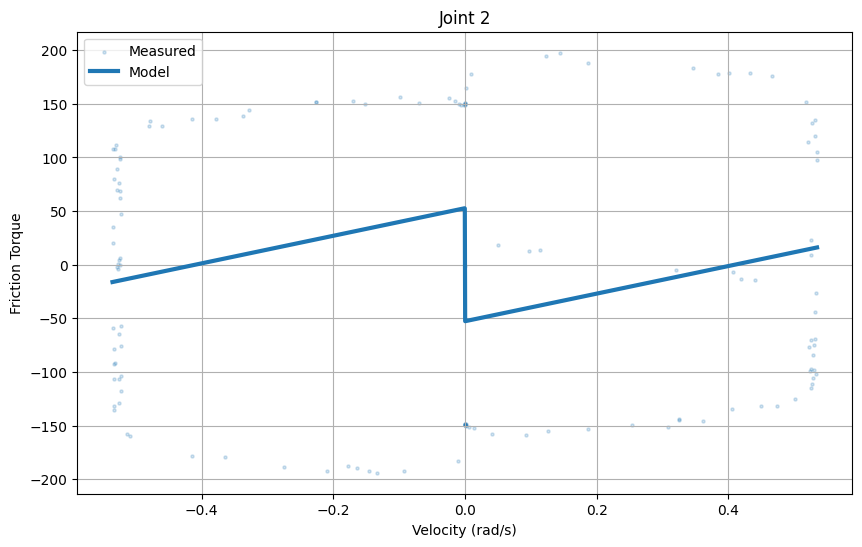


JOINT 3
Columns:
['m_t_3', 'jts3', 'v3', 'q3']

Train : (1337, 1)
Val : (191, 1)
Test : (383, 1)

Estimated Parameters
Tc = -11.880253160673835
Bv = 30.84291648756486
Vs = 0.002834122652943178

Validation R² = 0.0180

Performance
RMSE = 58.4185
MAE = 53.5177
R² = 0.0229


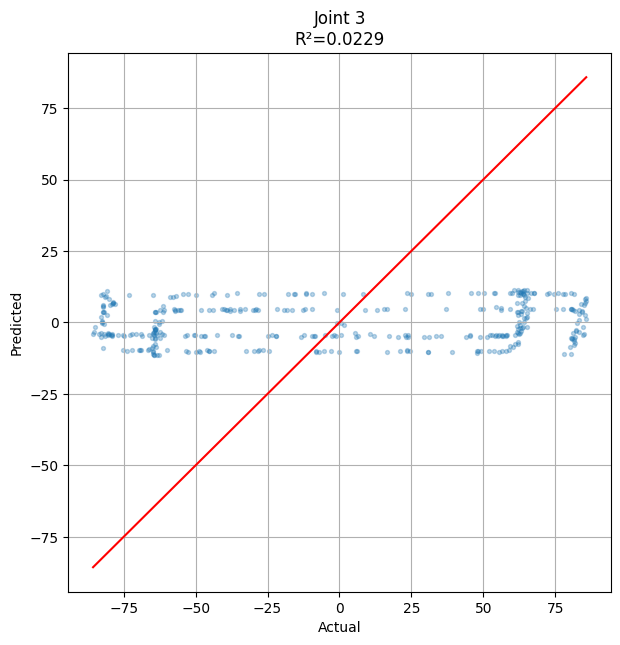

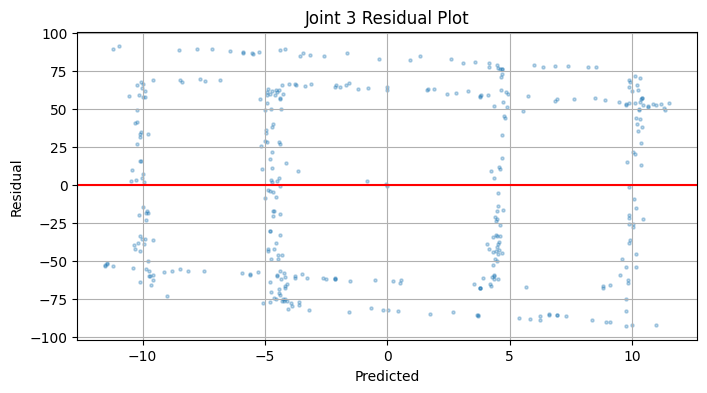

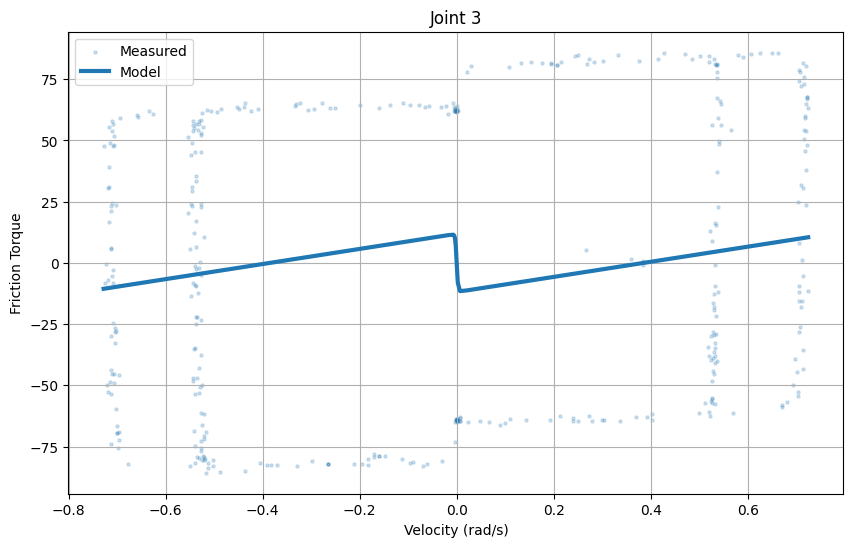


JOINT 5
Columns:
['m_t_5', 'jts5', 'v5', 'q5']

Train : (3663, 1)
Val : (523, 1)
Test : (1047, 1)

Estimated Parameters
Tc = 3.4898800984998464
Bv = 0.9178971137886143
Vs = 0.20578934740262608

Validation R² = 0.2006

Performance
RMSE = 7.5679
MAE = 6.9166
R² = 0.1992


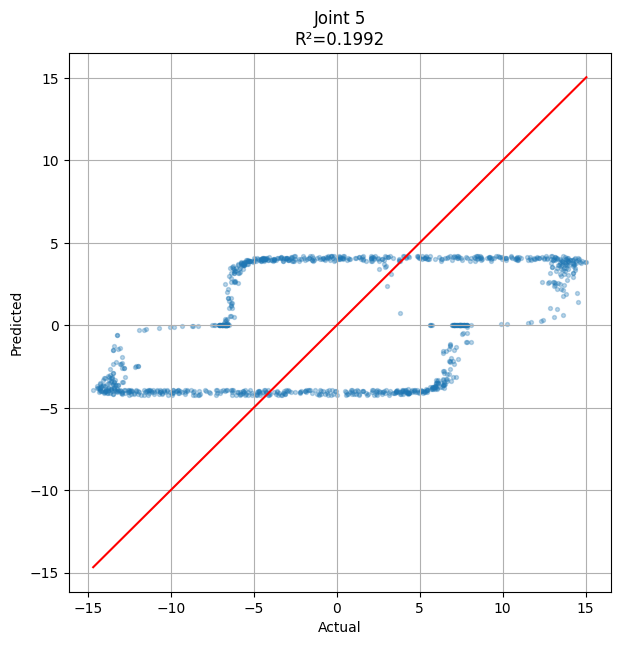

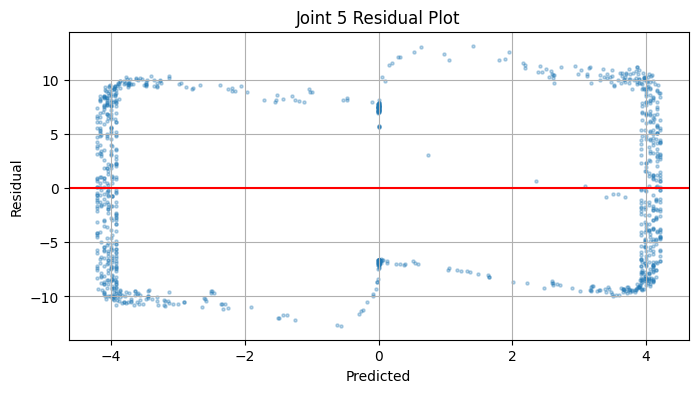

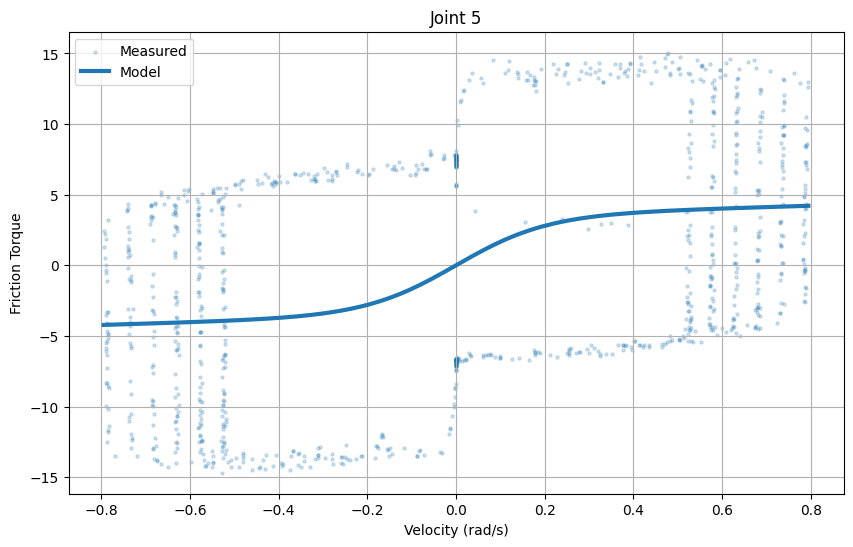

In [11]:
for joint, filename in work_files.items():
    print("\n" + "=" * 70)
    print(f"JOINT {joint}")
    print("="*70)

    # ==========================================
    # LOAD CSV
    # ==========================================
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    print("Columns:")
    print(df.columns.tolist())

    # ==========================================
    # CREATE COMMON COLUMNS
    # ==========================================
    df["v"] = np.deg2rad(df[f"v{joint}"])
    df["q"] = np.deg2rad(df[f"q{joint}"])
    df["tm"] = df[f"m_t_{joint}"]
    df["tj"] = df[f"jts{joint}"]
    df["tf"] = (N * df["tm"] - df["tj"])

    # ==========================================
    # FEATURES & TARGET
    # ==========================================
    X = df[["v"]].values
    y = df["tf"].values

    # ==========================================
    # TRAIN = 70%
    # TEMP  = 30%
    # ==========================================
    (X_train, X_temp, y_train, y_temp) = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

    # ==========================================
    # VAL = 10%
    # TEST = 20%
    # ==========================================
    (X_val, X_test, y_val, y_test) = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42, shuffle=True)
    print()
    print("Train :", X_train.shape)
    print("Val :", X_val.shape)
    print("Test :", X_test.shape)

    # ==========================================
    # FIT MODEL
    # ==========================================
    p0 = [5, 0.1, 0.01]
    params, _ = curve_fit(
        friction_model_unique,
        X_train.ravel(),
        y_train,
        p0=p0,
        maxfev=50000
    )

    Tc, Bv, Vs = params

    print("\nEstimated Parameters")
    print("Tc =", Tc)
    print("Bv =", Bv)
    print("Vs =", Vs)

    # ==========================================
    # VALIDATION
    # ==========================================
    val_pred = friction_model_unique(X_val.ravel(), *params)
    val_r2 = r2_score(y_val, val_pred)
    print(f"\nValidation R² = {val_r2:.4f}")

    # ==========================================
    # TEST
    # ==========================================

    pred = friction_model_unique(X_test.ravel(), *params)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print("\nPerformance")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"R² = {r2:.4f}")
    results.append([joint, Tc, Bv, Vs, rmse, mae, r2])

    # ==========================================
    # PLOT 1
    # Actual vs Predicted
    # ==========================================
    plt.figure(figsize=(7,7))
    plt.scatter(y_test, pred, s=8, alpha=0.3)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    plt.plot([mn,mx], [mn,mx], 'r')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Joint {joint}\nR²={r2:.4f}")
    plt.grid(True)
    plt.show()

    # ==========================================
    # PLOT 2
    # Residual
    # ==========================================
    residual = (y_test - pred)
    plt.figure(figsize=(8,4))
    plt.scatter(pred, residual, s=5, alpha=0.3)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Joint {joint} Residual Plot")
    plt.grid(True)
    plt.show()

    # ==========================================
    # PLOT 3
    # Friction Curve
    # ==========================================
    idx = np.argsort( X_test.ravel())
    plt.figure(figsize=(10,6))
    plt.scatter(X_test.ravel(), y_test, s=5, alpha=0.2, label="Measured")
    plt.plot(X_test.ravel()[idx], pred[idx], linewidth=3, label="Model")
    plt.xlabel("Velocity (rad/s)")
    plt.ylabel("Friction Torque")
    plt.title(f"Joint {joint}")
    plt.legend()
    plt.grid(True)
    plt.show()

# JOINT 2, 3, 5 GRAVITY TORQUE FUNC OF Q
# SUBSTRACTING GRAVITY LIKE t_f = t_raw - t_g

In [12]:
def friction_model(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v / Vs) + Bv * v)


JOINT 1
Columns:
['m_t_1', 'jts1', 'v1', 'q1']


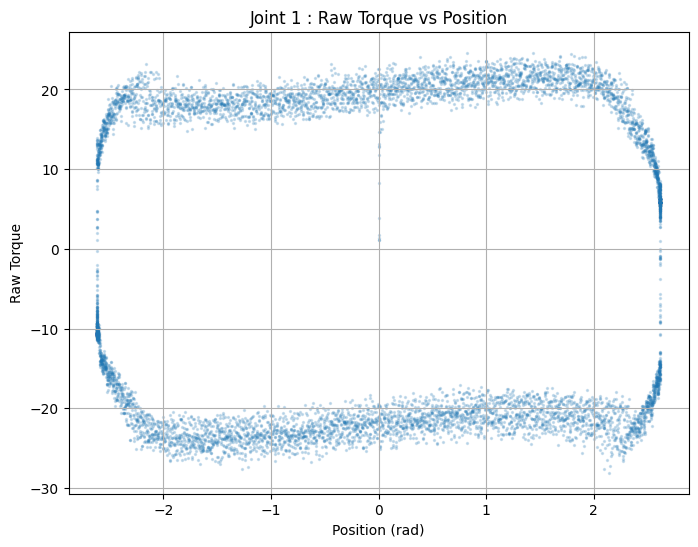


Train : (5396, 1)
Val : (771, 1)
Test : (1542, 1)

Friction Parameters
Joint 1 Tc = 9.614034
Joint 1 Bv = 17.528044
Joint 1 Vs = 0.000236

Validation R² = 0.9812

Performance
RMSE = 2.6019
MAE = 1.9599
R² = 0.9818


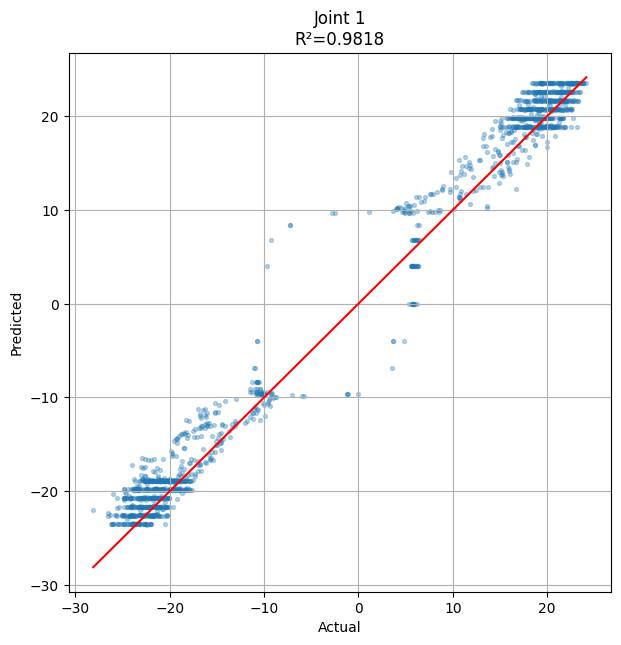

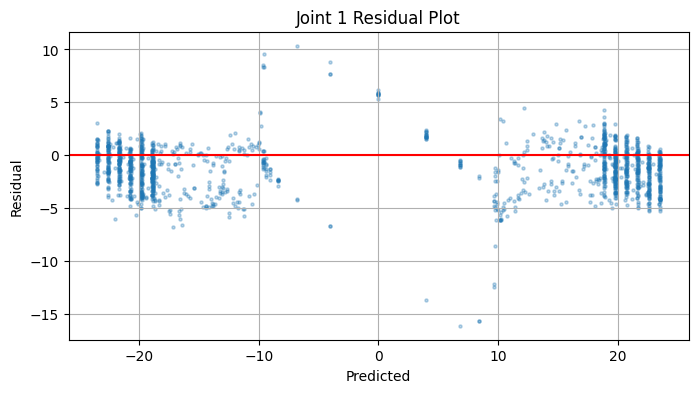

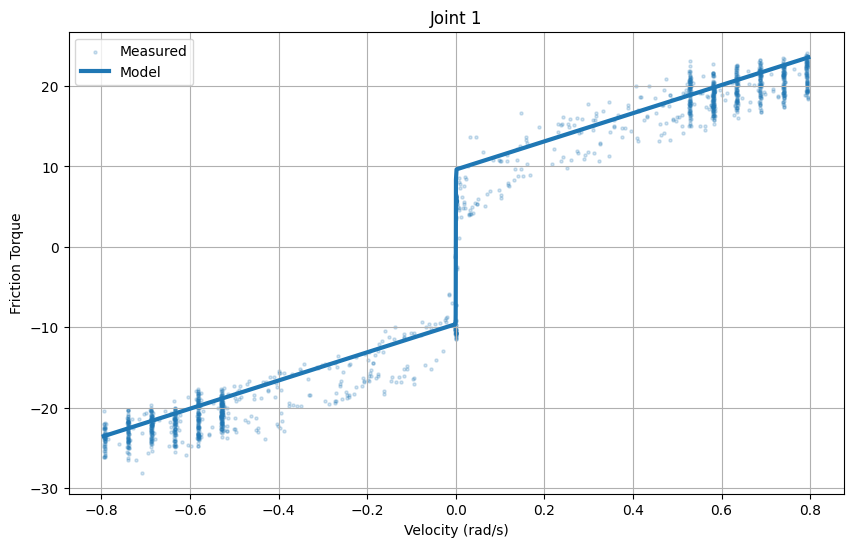


JOINT 2
Columns:
['m_t_2', 'jts2', 'v2', 'q2']


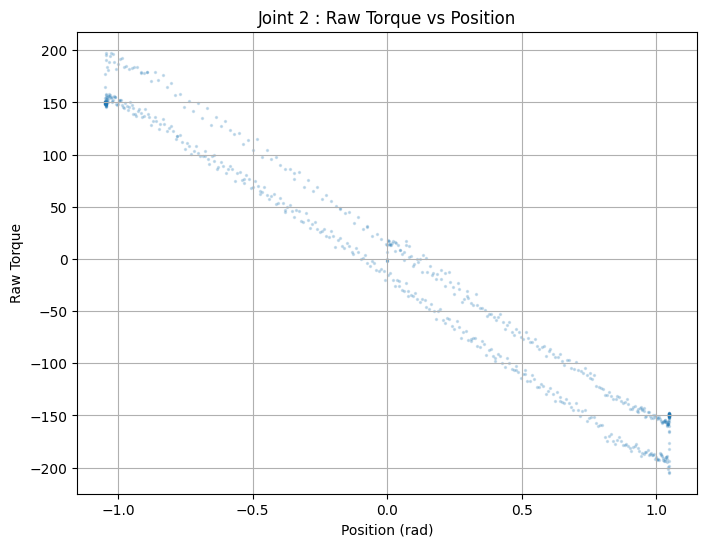


Gravity Parameters
Joint 2 a = -189.136655
Joint 2 b = 5.392886
Joint 2 c = -6.875352


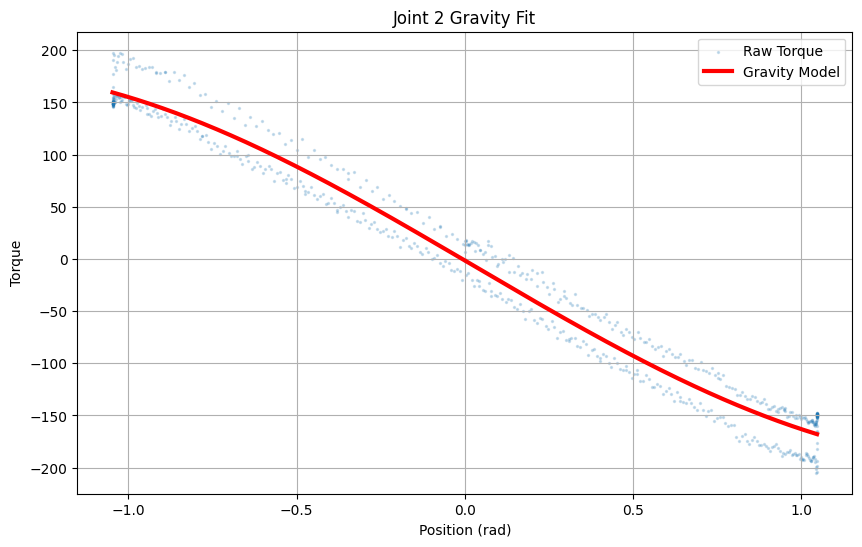

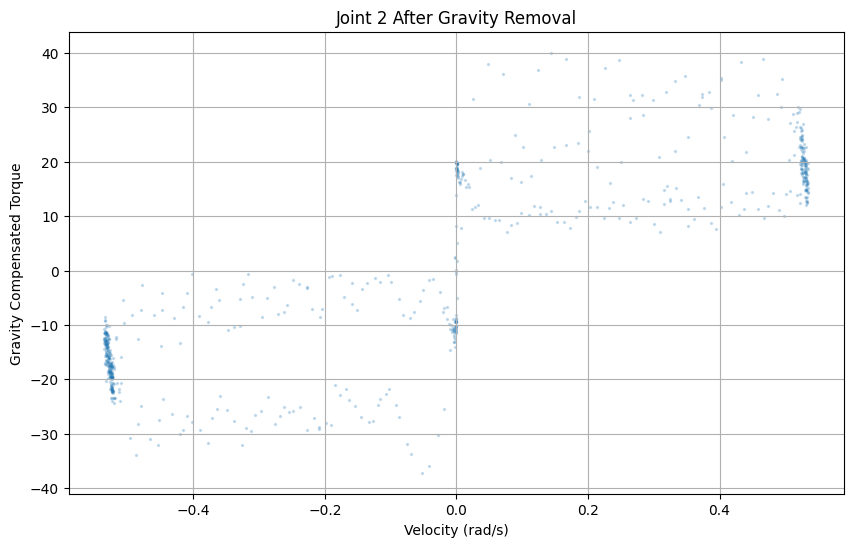


Train : (470, 1)
Val : (67, 1)
Test : (135, 1)

Friction Parameters
Joint 2 Tc = 14.623172
Joint 2 Bv = 6.843799
Joint 2 Vs = 0.000243

Validation R² = 0.8643

Performance
RMSE = 7.9004
MAE = 6.0181
R² = 0.8255


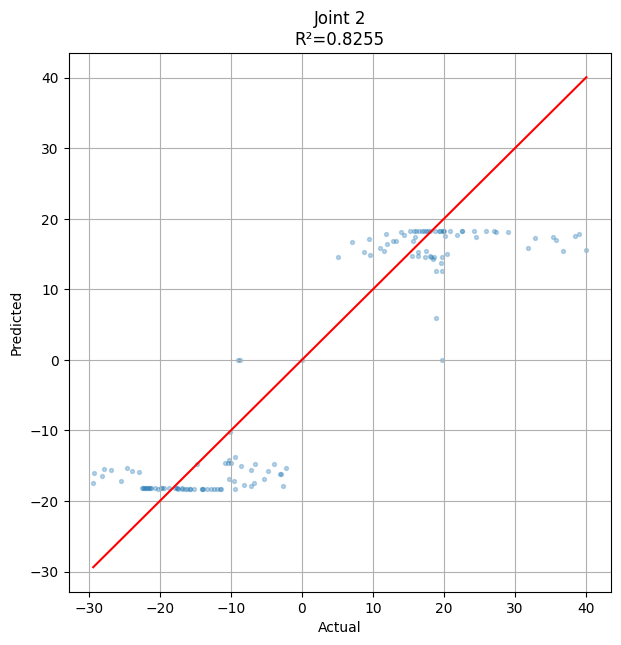

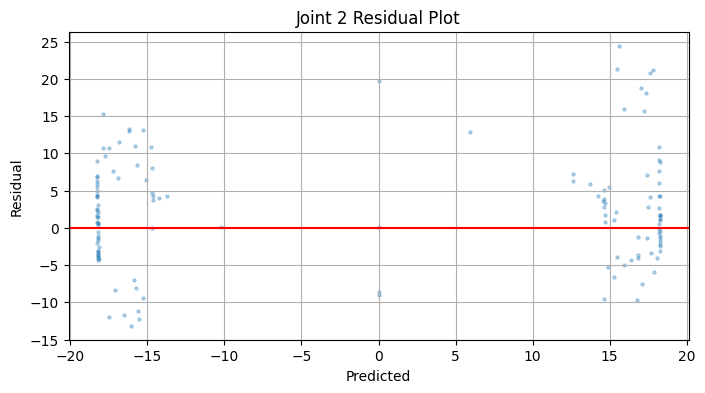

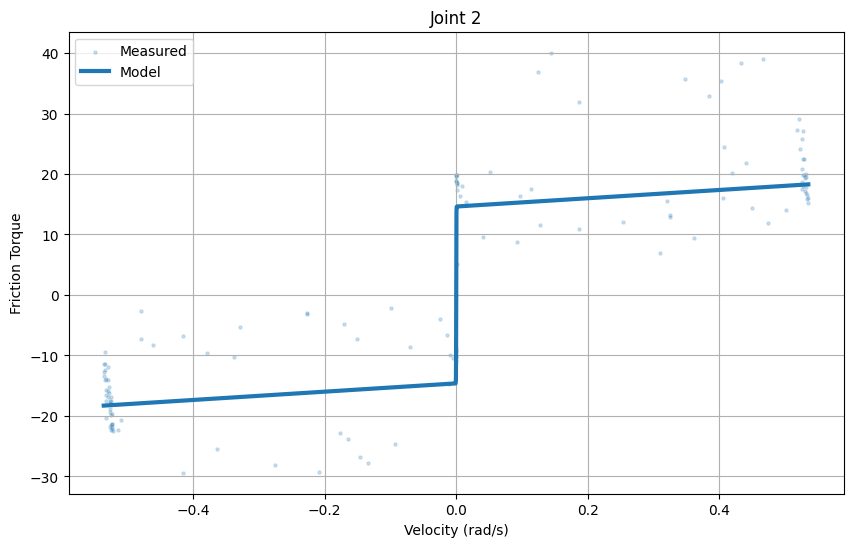


JOINT 3
Columns:
['m_t_3', 'jts3', 'v3', 'q3']


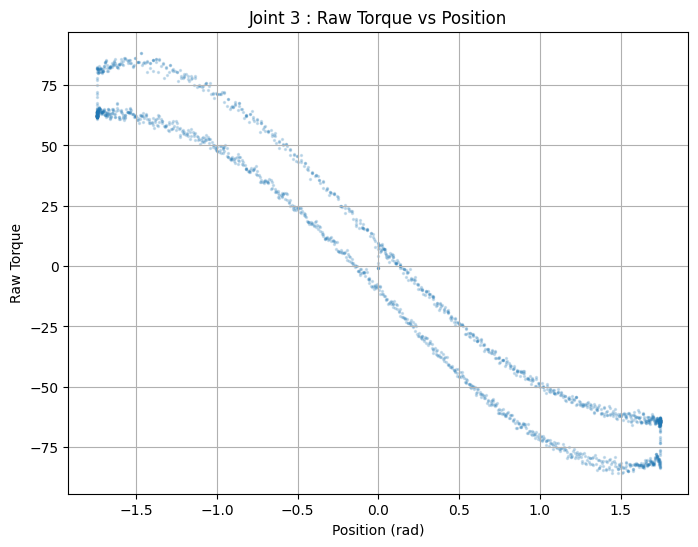


Gravity Parameters
Joint 3 a = -70.481769
Joint 3 b = -0.139577
Joint 3 c = -0.681270


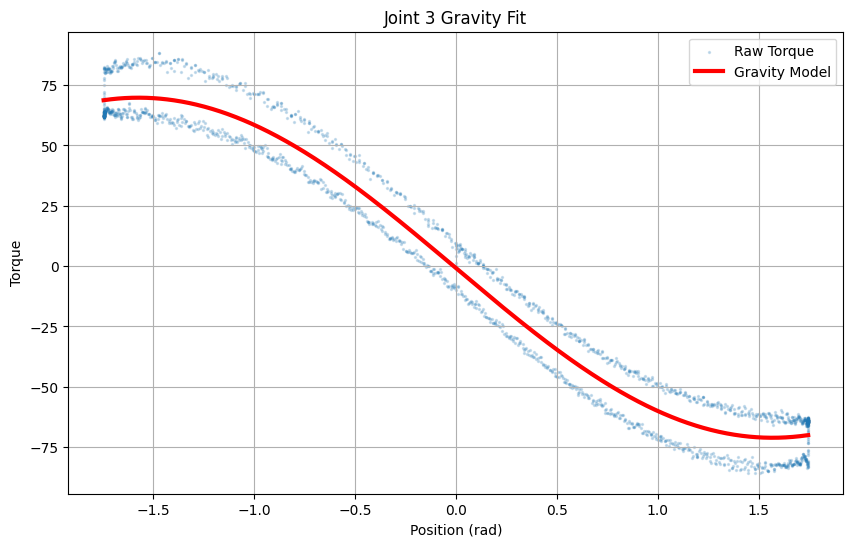

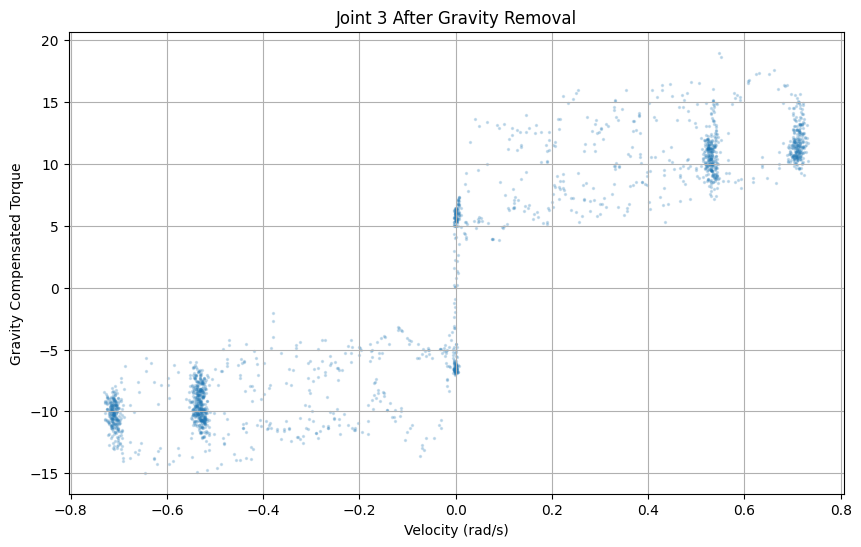


Train : (1337, 1)
Val : (191, 1)
Test : (383, 1)

Friction Parameters
Joint 3 Tc = 7.512197
Joint 3 Bv = 4.970059
Joint 3 Vs = 0.011579

Validation R² = 0.9313

Performance
RMSE = 2.7247
MAE = 2.1011
R² = 0.9289


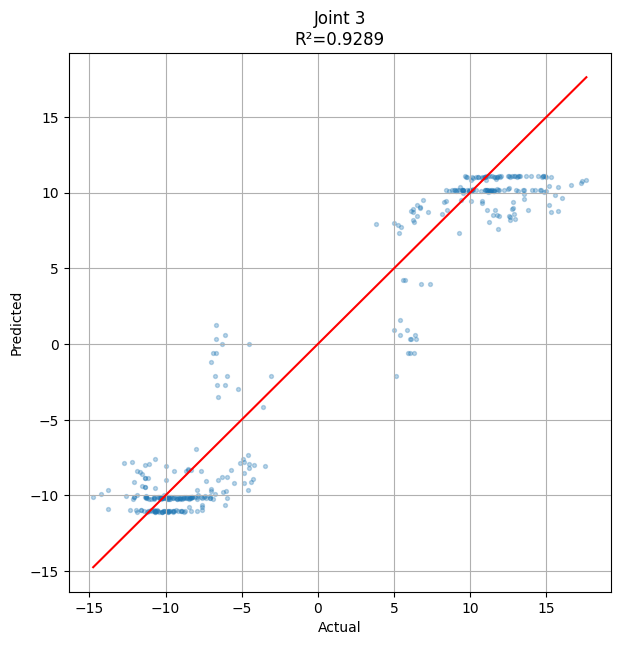

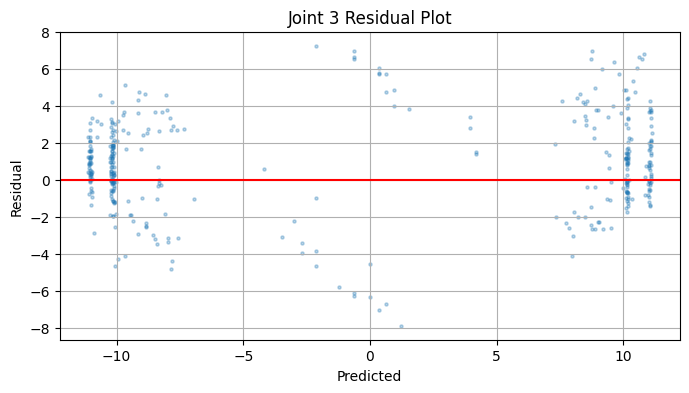

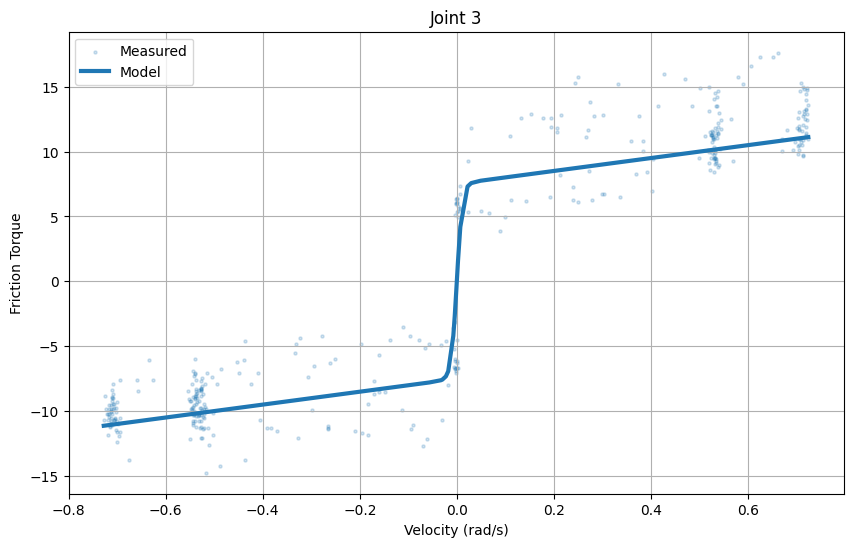


JOINT 5
Columns:
['m_t_5', 'jts5', 'v5', 'q5']


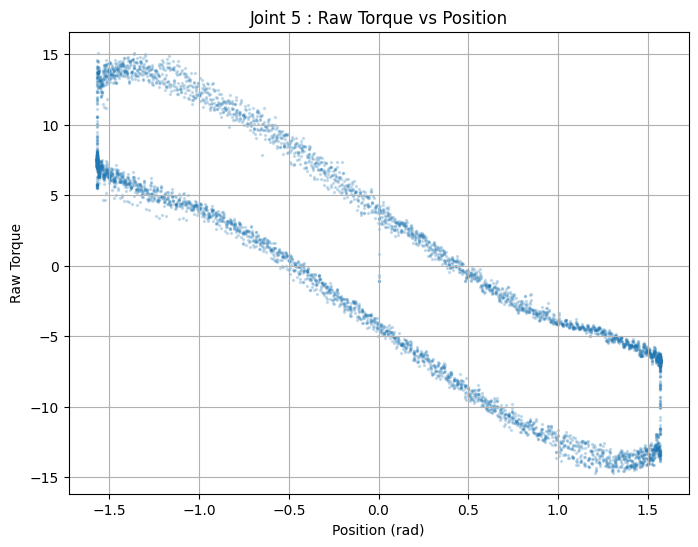


Gravity Parameters
Joint 5 a = -9.235360
Joint 5 b = -0.334148
Joint 5 c = 0.093607


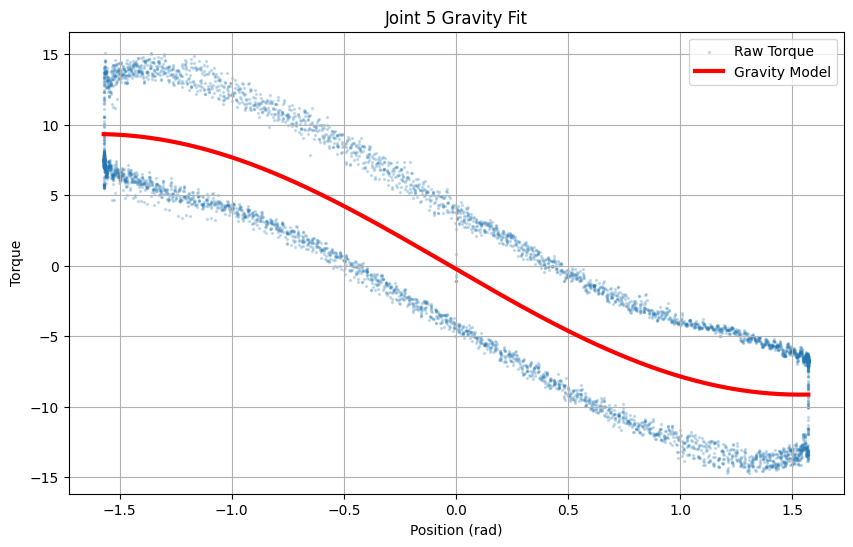

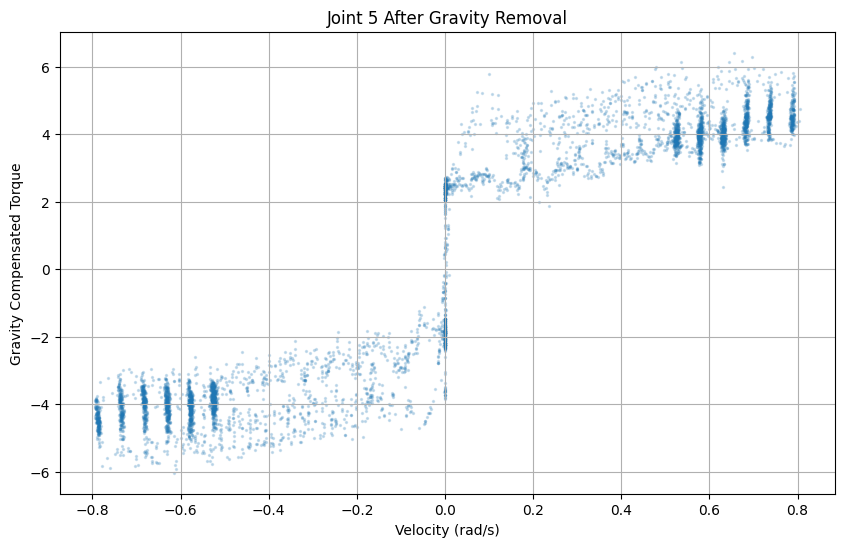


Train : (3663, 1)
Val : (523, 1)
Test : (1047, 1)

Friction Parameters
Joint 5 Tc = 2.982652
Joint 5 Bv = 1.940641
Joint 5 Vs = 0.006756

Validation R² = 0.9528

Performance
RMSE = 0.9080
MAE = 0.6553
R² = 0.9466


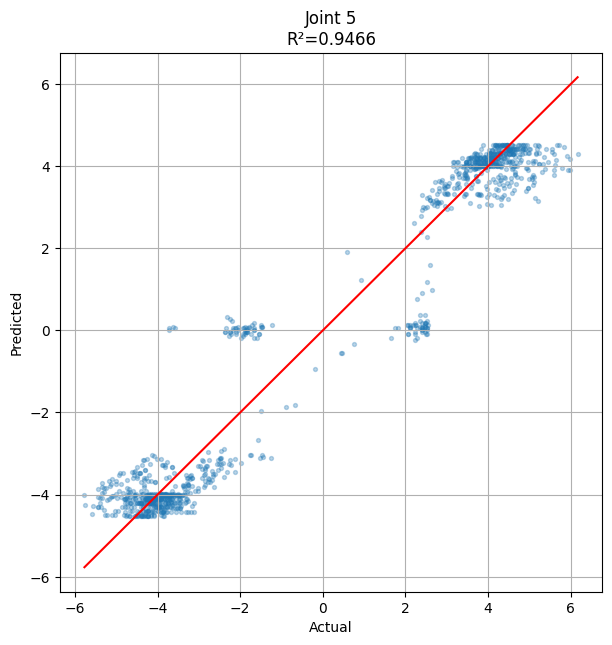

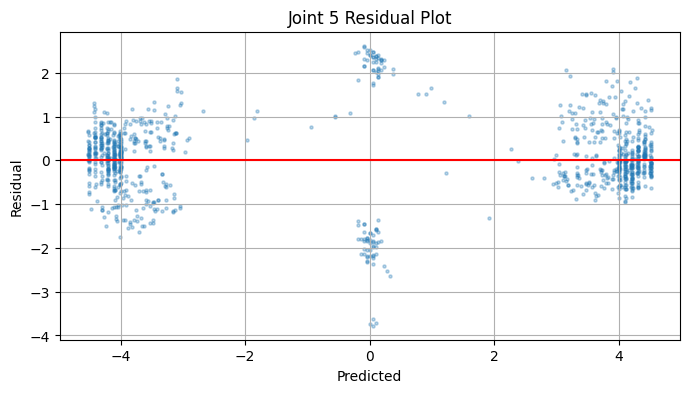

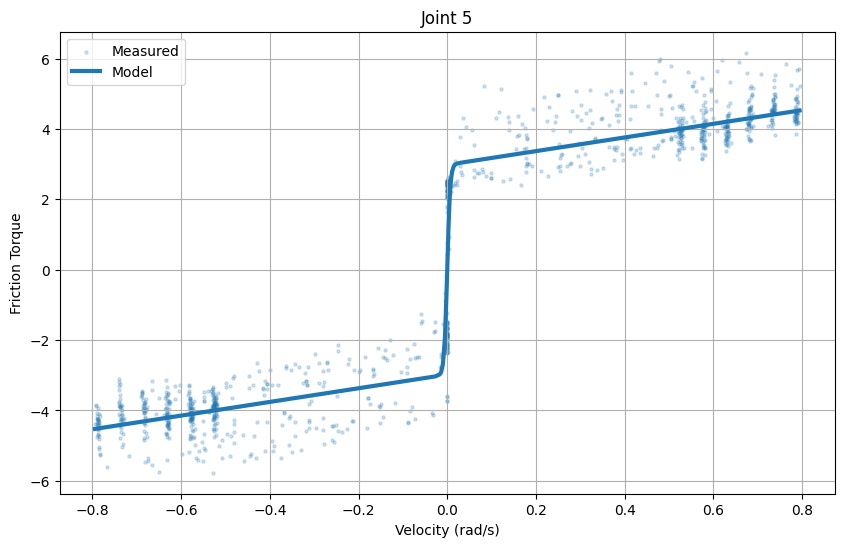


Gravity Parameters Summary


,Joint,a,b,c
0,2,-189.136655,5.392886,-6.875352
1,3,-70.481769,-0.139577,-0.681270
2,5,-9.235360,-0.334148,0.093607



Friction Parameters Summary


,Joint,Tc,Bv,Vs,RMSE,MAE,R2
0,1,9.614034,17.528044,0.000236,2.601869,1.959901,0.981799
1,2,14.623172,6.843799,0.000243,7.900408,6.018097,0.825493
2,3,7.512197,4.970059,0.011579,2.724739,2.101138,0.928890
3,5,2.982652,1.940641,0.006756,0.907953,0.655341,0.946566


In [ ]:
gravity_results = []
results = []

for joint, filename in work_files.items():
    print("\n" + "=" * 70)
    print(f"JOINT {joint}")
    print("=" * 70)

    # ==================================================
    # LOAD CSV
    # ==================================================
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    print("Columns:")
    print(df.columns.tolist())

    # ==================================================
    # CREATE COMMON COLUMNS
    # ==================================================
    df["v"] = np.deg2rad(df[f"v{joint}"])
    df["q"] = np.deg2rad(df[f"q{joint}"])
    df["tm"] = df[f"m_t_{joint}"]
    df["tj"] = df[f"jts{joint}"]
    df["tf_raw"] = (N * df["tm"] -df["tj"])

    # ==================================================
    # RAW TORQUE VS POSITION
    # ==================================================
    plt.figure(figsize=(8,6))
    plt.scatter(df["q"], df["tf_raw"], s=2, alpha=0.2)
    plt.xlabel("Position (rad)")
    plt.ylabel("Raw Torque")
    plt.title(f"Joint {joint} : Raw Torque vs Position")
    plt.grid(True)
    plt.show()

    # ==================================================
    # GRAVITY COMPENSATION
    # ==================================================
    if joint in [2, 3, 5]:
        def gravity_model(q, a, b, c):
            return (a * np.sin(q) + b * np.cos(q) + c)
        
        q_all = df["q"].values
        tf_all = df["tf_raw"].values
        p0_g = [50, 50, 0]
        grav_params, _ = curve_fit(
            gravity_model,
            q_all,
            tf_all,
            p0=p0_g,
            maxfev=50000
        )

        a, b, c = grav_params

        gravity_results.append([joint, a, b, c])
        print("\nGravity Parameters")
        print(f"Joint {joint} a = {a:.6f}")
        print(f"Joint {joint} b = {b:.6f}")
        print(f"Joint {joint} c = {c:.6f}")
        df["tau_g"] = gravity_model(df["q"], *grav_params)
        df["tf"] = (df["tf_raw"] - df["tau_g"])

        # ==========================================
        # GRAVITY FIT PLOT
        # ==========================================
        idx_q = np.argsort(df["q"].values)
        plt.figure(figsize=(10,6))
        plt.scatter(df["q"], df["tf_raw"], s=2, alpha=0.2, label="Raw Torque")
        plt.plot(df["q"].values[idx_q], df["tau_g"].values[idx_q], linewidth=3, color="red", label="Gravity Model")
        plt.xlabel("Position (rad)")
        plt.ylabel("Torque")
        plt.title(f"Joint {joint} Gravity Fit")
        plt.legend()
        plt.grid(True)
        plt.show()

        # ==========================================
        # AFTER GRAVITY REMOVAL
        # ==========================================
        plt.figure(figsize=(10,6))
        plt.scatter(df["v"], df["tf"], s=2, alpha=0.2)
        plt.xlabel("Velocity (rad/s)")
        plt.ylabel("Gravity Compensated Torque")
        plt.title(f"Joint {joint} After Gravity Removal")
        plt.grid(True)
        plt.show()

    else:
        df["tau_g"] = 0
        df["tf"] = df["tf_raw"]

    # ==================================================
    # FEATURES & TARGET
    # ==================================================
    X = df[["v"]].values
    y = df["tf"].values

    # ==================================================
    # TRAIN / VAL / TEST
    # ==================================================
    (X_train, X_temp, y_train, y_temp) = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)
    (X_val, X_test, y_val, y_test) = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42, shuffle=True)
    print()
    print("Train :", X_train.shape)
    print("Val :", X_val.shape)
    print("Test :", X_test.shape)

    # ==================================================
    # FIT FRICTION MODEL
    # ==================================================
    p0 = [5, 0.1, 0.01]
    params, _ = curve_fit(
        friction_model,
        X_train.ravel(),
        y_train,
        p0=p0,
        maxfev=50000
    )

    Tc, Bv, Vs = params

    print("\nFriction Parameters")
    print(f"Joint {joint} Tc = {Tc:.6f}")
    print(f"Joint {joint} Bv = {Bv:.6f}")
    print(f"Joint {joint} Vs = {Vs:.6f}")

    # ==================================================
    # VALIDATION
    # ==================================================
    val_pred = friction_model(X_val.ravel(), *params)
    val_r2 = r2_score(y_val, val_pred)
    print(f"\nValidation R² = {val_r2:.4f}")

    # ==================================================
    # TEST
    # ==================================================
    pred = friction_model(X_test.ravel(), *params)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print("\nPerformance")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"R² = {r2:.4f}")
    results.append([joint, Tc, Bv, Vs, rmse, mae, r2])

    # ==================================================
    # ACTUAL VS PREDICTED
    # ==================================================
    plt.figure(figsize=(7,7))
    plt.scatter(y_test, pred, s=8, alpha=0.3)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    plt.plot([mn,mx], [mn,mx], 'r')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Joint {joint}\nR²={r2:.4f}")
    plt.grid(True)
    plt.show()

    # ==================================================
    # RESIDUAL PLOT
    # ==================================================
    residual = (y_test - pred)
    plt.figure(figsize=(8,4))
    plt.scatter(pred, residual, s=5, alpha=0.3)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Joint {joint} Residual Plot")
    plt.grid(True)
    plt.show()

    # ==================================================
    # FRICTION CURVE
    # ==================================================
    idx = np.argsort(X_test.ravel())
    plt.figure(figsize=(10,6))
    plt.scatter(X_test.ravel(), y_test, s=5, alpha=0.2, label="Measured")
    plt.plot(X_test.ravel()[idx], pred[idx], linewidth=3, label="Model")
    plt.xlabel("Velocity (rad/s)")
    plt.ylabel("Friction Torque")
    plt.title(f"Joint {joint}")
    plt.legend()
    plt.grid(True)
    plt.show()

# ==================================================
# GRAVITY PARAMETERS TABLE
# ==================================================
gravity_df = pd.DataFrame(
    gravity_results,
    columns=[
        "Joint",
        "a",
        "b",
        "c"
    ]
)
print("\nGravity Parameters Summary")
display(gravity_df)

# ==================================================
# FRICTION PARAMETERS TABLE
# ==================================================
results_df = pd.DataFrame(
    results,
    columns=[
        "Joint",
        "Tc",
        "Bv",
        "Vs",
        "RMSE",
        "MAE",
        "R2"
    ]
)
print("\nFriction Parameters Summary")
display(results_df)